## Welcome to the Mid-term project!

This project is designed for you to update and reinforce the knowledge you have gained in the first months of the "Machine Learning for People" course.

### Main Task

In this assignment, you are a Data Scientist at a bank. Your task is to build a model to predict whether a client will sign a term deposit at the bank. We encounter similar tasks in various companies and domains when we want to understand whether a client will purchase a product, use our service/website in the next month, or subscribe.

You need to not only build a model but also explain to the client (your client here is us with the curators) how this model works and why it makes such decisions. Without this understanding, we cannot proceed to the deployment of the model in production.

### Practical Application

In real working conditions for similar tasks, your data will be stored in a database dynamically (various user actions with date and time). Here, the data is already aggregated by clients, and often this is where you will start building the prediction model, as it is relatively simple and convenient: aggregate data by clients up to a certain time and predict into the future (only in the case of training the ML model, our "future" is also actually in the past - because we want to have labels in the data, but when using the model in production and real conditions, you will indeed be making predictions into the future). So, let's solve the task!

### Dataset and ML Task

To complete the assignment, we will use a dataset that originally comes from the [UCI Machine Learning Repository], but there is an inaccurate description of the data and many different subsets, so we will take the dataset from Kaggle: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

This data pertains to direct marketing campaigns (telephone calls) of a Portuguese banking institution. The ultimate goal of the classification is to predict whether the client will sign a term deposit (variable y).

We will work with the file `bank-additional-full.csv`, and you need to download the dataset from Kaggle. Alternatively, you can download the same dataset from Google Drive [here](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link).

### Description of Variables

This description is also available on Kaggle, but we have translated it for your convenience so that you have it in front of you while working on the project.

#### **Bank Client Data**:
1. **age** – age of the client (numerical variable).  
2. **job** – type of employment (categorical variable: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – marital status (categorical variable: `divorced`, `married`, `single`, `unknown`; note: `divorced` means divorced or widowed).  
4. **education** – level of education (categorical variable: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – does the client have a credit default? (categorical variable: `no`, `yes`, `unknown`).  
6. **housing** – does the client have a housing loan? (categorical variable: `no`, `yes`, `unknown`).  
7. **loan** – does the client have a personal loan? (categorical variable: `no`, `yes`, `unknown`).  

#### **Data on the Last Contact within the Current Marketing Campaign**:
8. **contact** – type of communication during the last contact (categorical variable: `cellular`, `telephone`).  
9. **month** – month of the last contact (categorical variable: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – day of the week of the last contact (categorical variable: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – duration of the last contact in seconds (numerical variable).  
   ⚠ **Important Note**: this variable has a significant impact on the target variable (for example, if duration = 0, then y = `no`). However, the value of duration is unknown until the call is made. Moreover, after the call ends, the value of y is already known. Therefore, this variable should only be used for model comparison, but not included in the final predictive model.  

#### **Other Attributes**:
12. **campaign** – number of contacts within the current campaign for this client (numerical variable, includes the last contact).  
13. **pdays** – number of days since the client was last contacted in the previous campaign (numerical variable; a value of 999 means that the client was not previously contacted).  
14. **previous** – number of contacts made before this campaign for this client (numerical variable).  
15. **poutcome** – outcome of the previous marketing campaign (categorical variable: `failure`, `nonexistent`, `success`).  

#### **Social-Economic Context Attributes**:
16. **emp.var.rate** – employment variation rate (quarterly indicator, numerical variable).  
17. **cons.price.idx** – consumer price index (monthly indicator, numerical variable).  
18. **cons.conf.idx** – consumer confidence index (monthly indicator, numerical variable).  
19. **euribor3m** – Euribor rate for 3 months (daily indicator, numerical variable).  
20. **nr.employed** – number of employed persons (quarterly indicator, numerical variable).  

#### **Target Variable**:
21. **y** – did the client sign a term deposit? (binary variable: `yes`, `no`).

### Your Task for This Project

You need to build a solution for this binary classification task. To do this:

1. Conduct Exploratory Data Analysis and formulate hypotheses about the impact of individual features on the target feature `y`.

2. Describe which methods you consider appropriate to use and choose a metric for evaluating the quality of the models (the metric should be justified).

3. Perform data preprocessing for further input into the model. Preprocessing should include:
  - handling categorical variables (if required by the model)
  - grouping categories in categorical variables, if necessary
  - filling in missing values, if any
  - detecting outliers and making decisions on how to handle them
  - creating additional features that you believe will improve the quality of the ML models.

4. Train 4 different types of machine learning models, including:
  - Logistic Regression
  - kNN
  - Decision Tree
  - At least one boosting algorithm

5. Create a table comparing the quality of the models (in Google Spreadsheets or directly in Jupyter Notebook), indicating:
  - model name
  - hyperparameters
  - quality metric of the model on the training set
  - quality metric of the model on the validation dataset
  - comments on the model - whether it is good or not, whether it should be used or not, and if you have further ideas for experiments with this model?

6. For the boosting algorithm, perform hyperparameter tuning in two ways:
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Identify the optimal hyperparameters and draw conclusions about the model's quality in each case.

7. Output the feature importance for the model that performed best and describe whether you consider this priority of feature importance adequate from a common sense perspective.

8. For the best model, conduct an analysis of the impact of features on predictions using the SHAP library.

9. Analyze the records where the model makes mistakes and based on this, indicate how the existing solution can be improved to avoid current errors.

### Project Outcome

The result of this assignment is a separate GitHub repository with a neatly formatted Jupyter Notebook, with some code possibly moved to .py files. The repository should contain a description of the task, a description of what was done and which models were used, a table of experiment results (which can be a screenshot or a table created in Markdown format - see example), and conclusions about what you achieved and what could still be done to improve the results.

### Example Project

For inspiration, you can check out a project built on this data at [this link](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project). 

![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',30)
pd.set_option('float_format', '{:.2f}'.format)

# Data Import

In [4]:
raw_df = pd.read_csv("bank-additional-full.csv", sep=';')
# Overview of the records from the dataframe
display(raw_df.head())
print('Dataframe shape:', raw_df.shape)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


Dataframe shape: (41188, 21)


In [5]:
df = raw_df.copy()

# Let's check the data for duplicates

In [7]:
df.duplicated().sum()

np.int64(12)

So, there are 12 rows with duplicate information in the dataset. This is not much for such a dataset, but the probability that all combinations of columns match for different clients is quite low. Therefore, these rows will be removed.

In [9]:
df = df[~df.duplicated()].reset_index(drop=True)  # Remove duplicates and reset index

# Working with missing values

In [11]:
# Let's check if there are any missing rows in the dataset
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

So, the data does not have any missing values and we do not need to fill them in.

# Analysis of Categorical Variables

In [14]:
# Checking the number of categorical variables
print('Number of categorical variables:', len(df.select_dtypes(include = "object").columns))

# Let's check the number of unique data and the share of the most common values in the columns
summary = df.describe(include='object').T
summary['freq_%'] = (summary['freq'].astype(float) / summary['count'].astype(float) * 100).round(2)
display(summary)
del(summary)

Number of categorical variables: 11


,count,unique,top,freq,freq_%
job,41176,12,admin.,10419,25.30
marital,41176,4,married,24921,60.52
education,41176,8,university.degree,12164,29.54
default,41176,3,no,32577,79.12
housing,41176,3,yes,21571,52.39
loan,41176,3,no,33938,82.42
contact,41176,2,cellular,26135,63.47
month,41176,10,may,13767,33.43
day_of_week,41176,5,thu,8618,20.93
poutcome,41176,3,nonexistent,35551,86.34


Based on the data in the table, we can say that:
- The dataset has a strong imbalance in the target column (≈89% "no"), which makes accuracy an unreliable metric for future prediction models.
- Most categorical variables have dominant values (for example, poutcome, loan, default), which may reduce their informativeness and require additional verification of their impact on the target.

In [16]:
cat_cols = df.select_dtypes('object').columns[:-1].tolist()
print('Categorical columns:', cat_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [17]:
# Let's create a function that will help us analyze each categorical column.
from pandas.api.types import is_object_dtype, is_categorical_dtype

def plot_category_overview(
    df: pd.DataFrame,
    col: str,
    target_col: str,
    positive_class=None,
    hue_order: list | None = None,
    palette: dict | list | None = None,
    figsize: tuple[int, int] = (16, 6)
) -> None:
    """
    Display two plots for one categorical column:
    1) countplot by target
    2) selected class rate by category

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    col : str
        Categorical column to analyze.
    target_col : str
        Target column name.
    positive_class : any | list | tuple | set, default=None
        One target value or multiple target values treated as the selected class
        for rate calculation.
        Examples:
        positive_class='yes'
        positive_class=1
        positive_class=['False Positive', 'False Negative']
    hue_order : list | None, default=None
        Order of target classes in the countplot legend and grouped bars.
        If None, the order is inferred from the data.
    palette : dict | list | None, default=None
        Colors for target classes.
    figsize : tuple[int, int], default=(16, 6)
        Figure size.

    Returns
    -------
    None
        Displays plots only.

    Raises
    ------
    ValueError
        If column names are invalid or positive_class values are missing in target.
    TypeError
        If the selected feature is not categorical.
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' is not in DataFrame.")

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' is not in DataFrame.")

    if not (is_object_dtype(df[col]) or is_categorical_dtype(df[col])):
        raise TypeError(f"Column '{col}' must be categorical or object dtype.")

    target_values = df[target_col].dropna().unique().tolist()

    if hue_order is None:
        hue_order = sorted(target_values, key=lambda x: str(x))

    missing_hue = [v for v in hue_order if v not in target_values]
    if missing_hue:
        raise ValueError(f"Values {missing_hue} from hue_order are absent in '{target_col}'.")

    if positive_class is None:
        raise ValueError(
            "positive_class must be provided. "
            "Example: positive_class='yes' or positive_class=['False Positive', 'False Negative']."
        )

    if isinstance(positive_class, (list, tuple, set)):
        positive_classes = list(positive_class)
    else:
        positive_classes = [positive_class]

    missing_positive = [v for v in positive_classes if v not in target_values]
    if missing_positive:
        raise ValueError(
            f"Values {missing_positive} from positive_class are absent in target column '{target_col}'."
        )

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=figsize)

    # ===== Left plot =====
    ax = axes[0]
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        hue=target_col,
        order=order,
        palette=palette,
        ax=ax,
        hue_order=hue_order
    )

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.legend(title=target_col, loc='upper right')
    ax.tick_params(axis='x', rotation=90)

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, fmt='%d')

    # ===== Right plot =====
    ax = axes[1]

    rates = (
        df.groupby(col)[target_col]
        .apply(lambda s: s.isin(positive_classes).mean() * 100)
        .sort_values(ascending=True)
    )

    bars = ax.barh(rates.index, rates.values, color='#277da1')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

    if len(positive_classes) == 1:
        right_title = f"{col} — {positive_classes[0]} Rate"
        x_label = f"% {positive_classes[0]}"
    else:
        joined_classes = " + ".join(map(str, positive_classes))
        right_title = f"{col} — {target_col} = {positive_class}"
        x_label = f"% ({joined_classes})"

    ax.set_title(right_title, fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_xlim(0, rates.max() * 1.25 if rates.max() > 0 else 100)

    plt.suptitle(f'Categorical Feature Overview: {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Analysis of the 'job' column

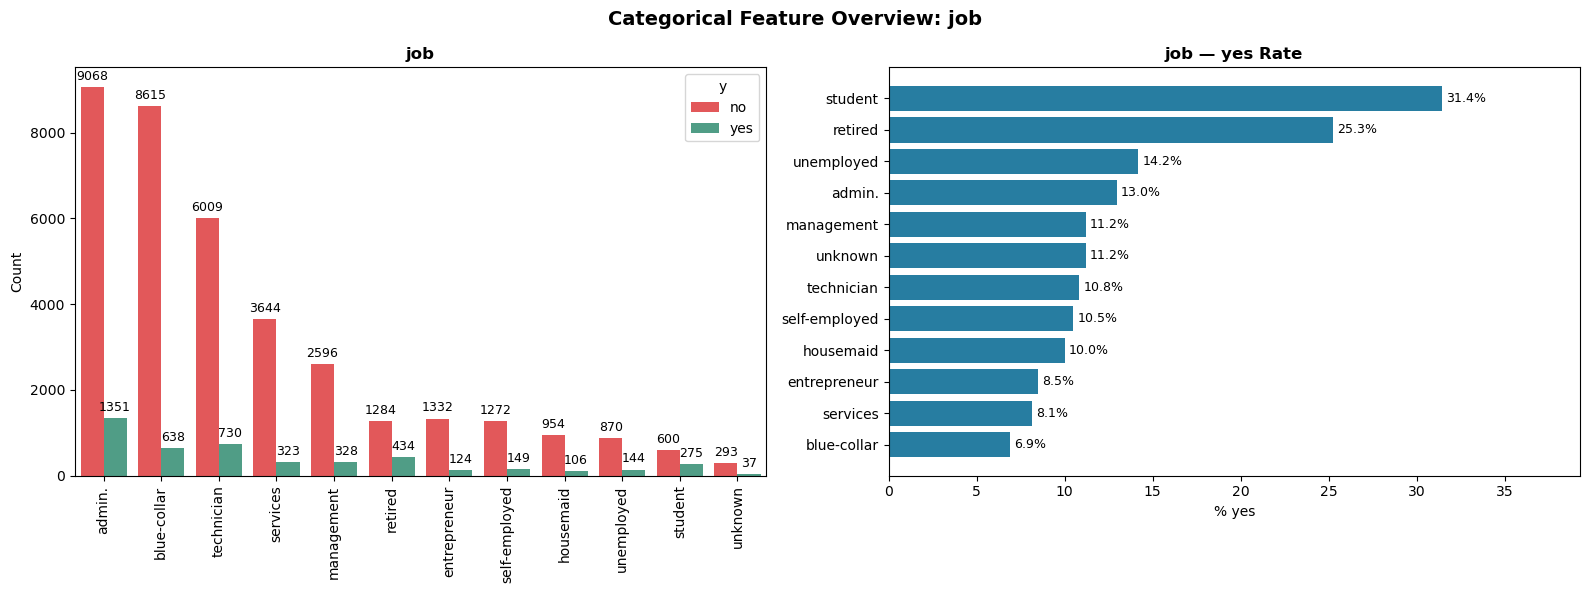

In [19]:
plot_category_overview(
    df=df,
    col=cat_cols[0],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The graphs show that students and retirees have the highest probability of signing a term deposit, while, for example, blue-collar workers provide a large volume but the worst positive rate.

Special attention should be paid to the small number of clients in the unknown category, whose positive rate is identical to that of the management category. As an option, it is quite possible to combine these two categories, but I would prefer to leave everything as it is.

### Analysis of the 'marital' column

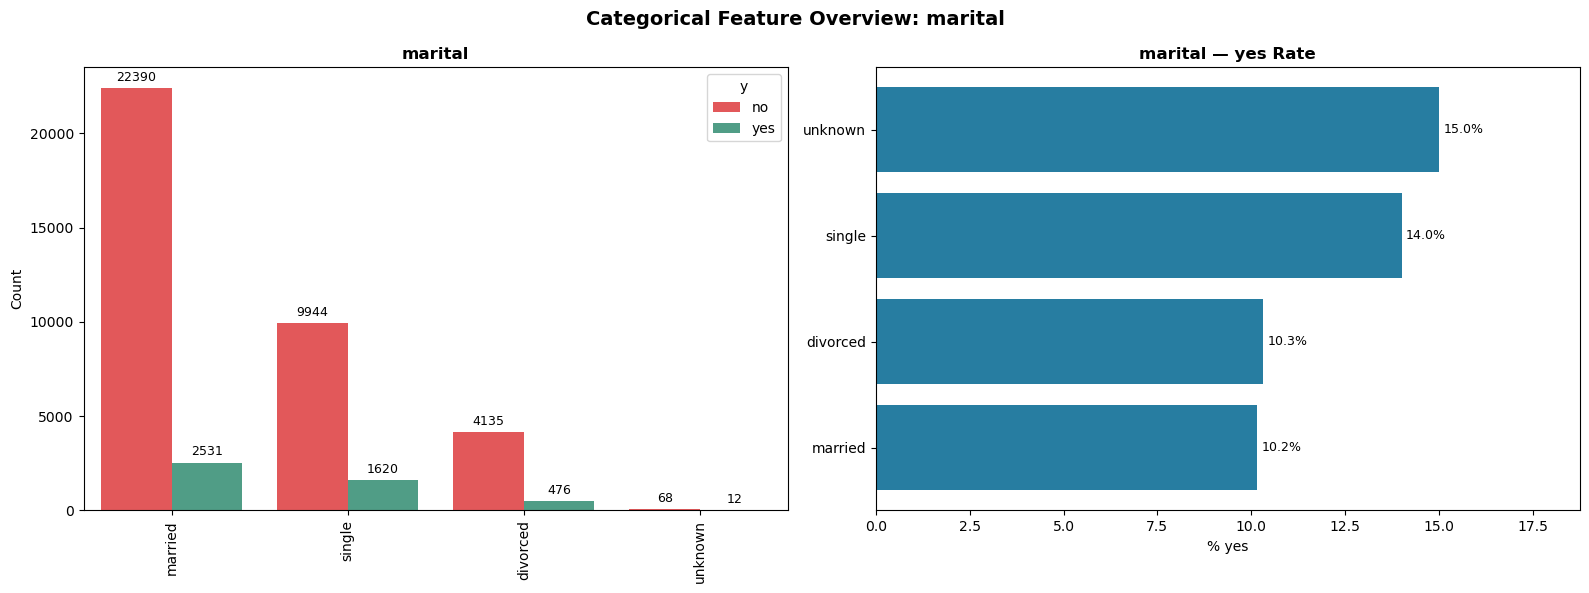

In [22]:
plot_category_overview(
    df=df,
    col=cat_cols[1],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Single clients have the highest subscription probability (14%), while married and divorced individuals show a lower level (~10%).

This category also contains unknown values (a total of 80 values), which are perceived more as noise.

In general, since married and divorced show approximately the same positive rate, and unknown is not significant, I will combine these three values into the value 'not_single'.

In [25]:
df['marital'] = np.where(df['marital'] == 'single', 'single', 'not_single')

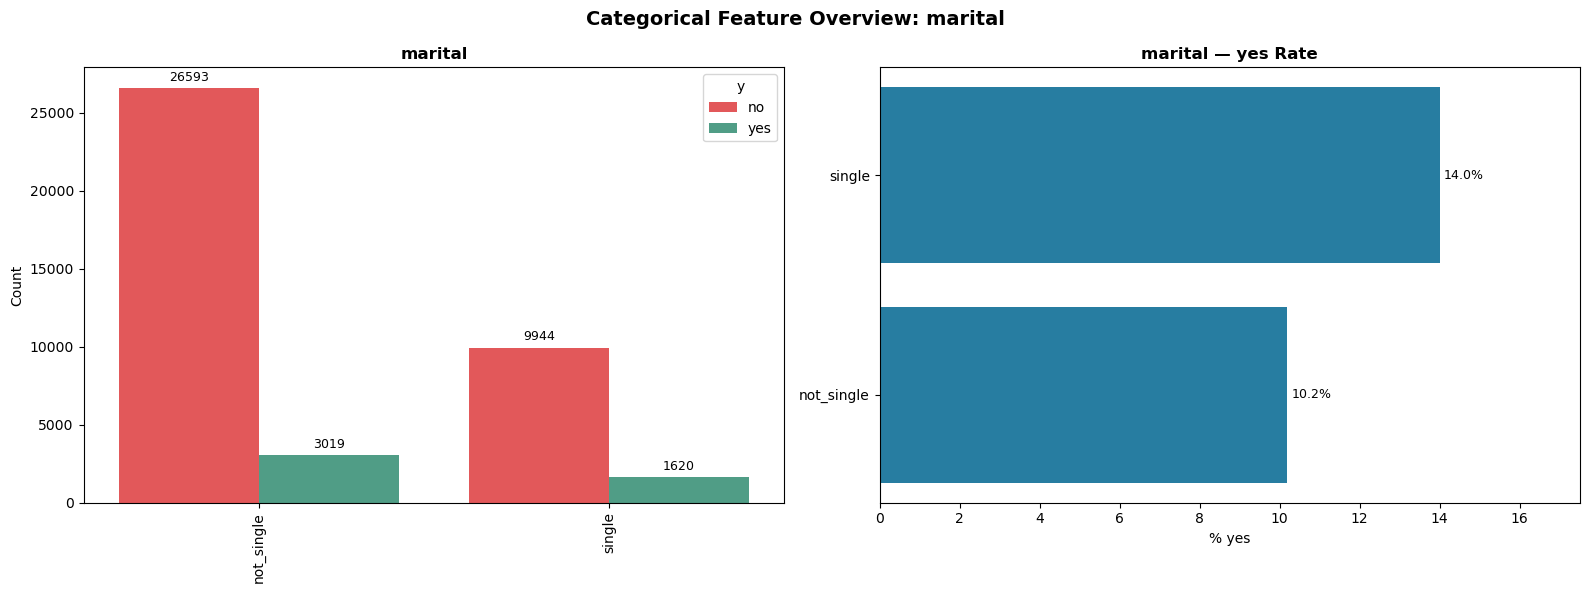

In [26]:
# I will build the graph again
plot_category_overview(
    df=df,
    col=cat_cols[1],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Now the column has fewer values that are similar in meaning.

### Analysis of the 'education' column

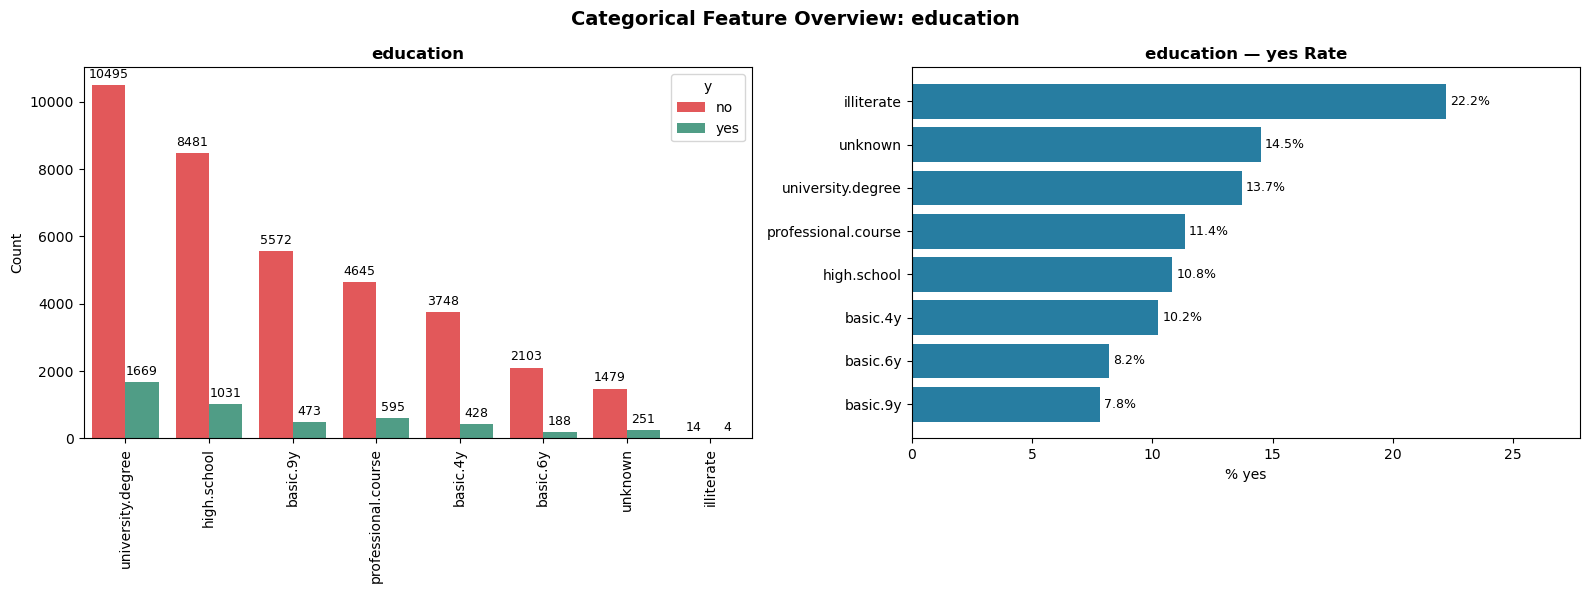

In [29]:
plot_category_overview(
    df=df,
    col=cat_cols[2],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Education shows a clear correlation: higher education is associated with a greater likelihood of subscription, while lower levels of education are associated with a lesser likelihood.

An interesting situation arises with clients who have the value illiterate, as they have only 18 entries in the dataset, but show a quite high rate of ~22%. I am quite curious if there are any other factors that influence such a high indicator, so I will analyze these clients' data in more detail.

In [31]:
df[df.education == 'illiterate']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
5392,45,blue-collar,not_single,illiterate,unknown,no,yes,telephone,may,fri,333,2,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
6927,45,blue-collar,not_single,illiterate,unknown,no,no,telephone,may,thu,1196,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
12381,51,admin.,not_single,illiterate,unknown,no,no,cellular,jul,mon,151,4,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
14442,55,blue-collar,not_single,illiterate,no,yes,no,cellular,jul,tue,92,3,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
14483,55,blue-collar,not_single,illiterate,no,no,no,cellular,jul,tue,129,2,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
16266,60,housemaid,not_single,illiterate,unknown,yes,no,cellular,jul,tue,176,7,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
17735,54,blue-collar,not_single,illiterate,unknown,yes,yes,cellular,jul,tue,83,1,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
22395,45,blue-collar,not_single,illiterate,no,yes,no,cellular,aug,fri,127,1,999,0,nonexistent,1.40,93.44,-36.10,4.96,5228.10,no
22635,44,blue-collar,not_single,illiterate,no,no,no,cellular,aug,fri,460,1,999,0,nonexistent,1.40,93.44,-36.10,4.96,5228.10,no
26672,34,self-employed,not_single,illiterate,no,yes,no,cellular,nov,thu,51,1,999,0,nonexistent,-0.10,93.20,-42.00,4.08,5195.80,no


The first thing I noticed in this table is the large number of blue-collar workers, whom I previously marked as clients with the lowest positive rate. The other columns do not seem to have as significant an impact, so let's create graphs displaying the statistics by job.

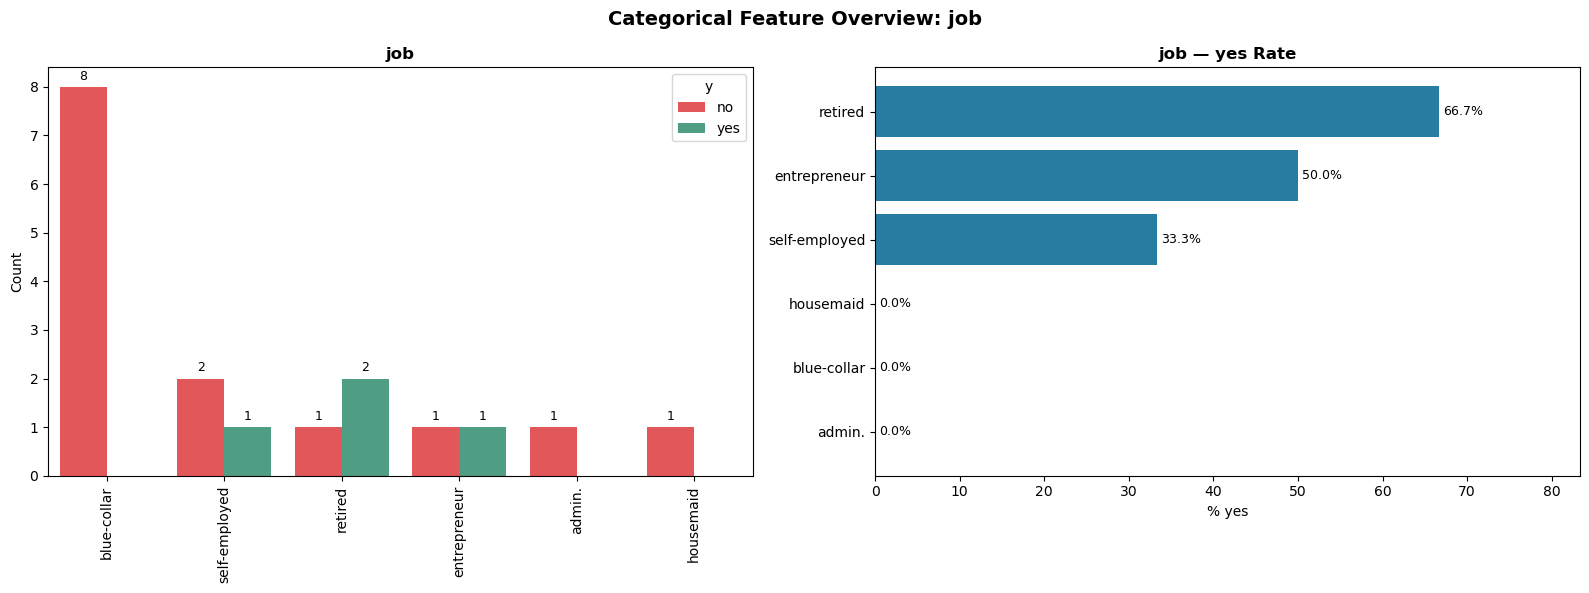

In [33]:
plot_category_overview(
    df=df[df.education == 'illiterate'],  # Filter the dataframe for illiterate individuals
    col=cat_cols[0],  # Specify the first categorical column
    target_col='y',  # Specify the target column
    positive_class='yes',  # Define the positive class
    hue_order=['no', 'yes'],  # Set the order of hues
    palette={'yes': '#43aa8b', 'no': '#f94144'}  # Define the color palette
)

The graph clearly shows that the largest number of illiterate clients who signed a term deposit are retired. I have already noted this category due to its high positive rate. In contrast, blue-collar clients have the highest values, but no positive values in the target column.

### Analysis of the 'default' column

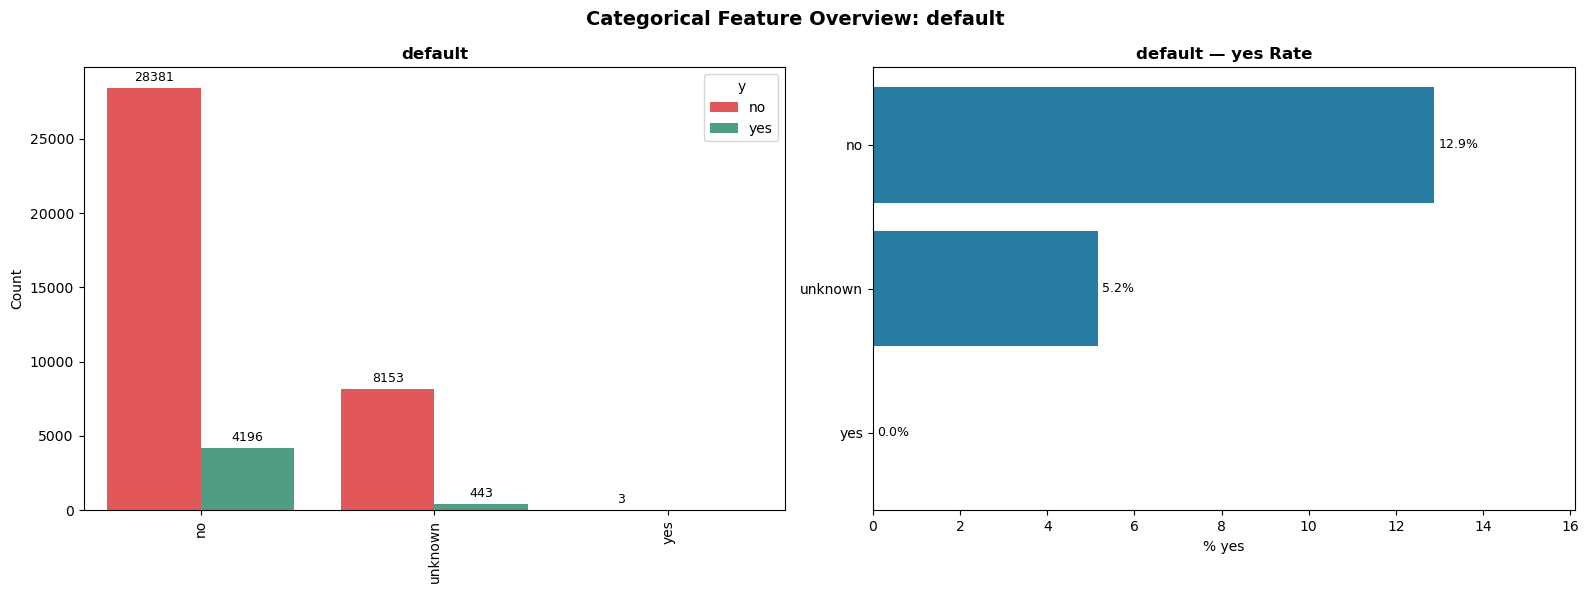

In [36]:
plot_category_overview(
    df=df,
    col=cat_cols[3],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The column is characterized by a strong class imbalance: the value "no" accounts for almost 80% of the data and has a positive rate of 12.9%. The value "yes" is represented by only 3 observations, so it has no statistical value. The value "unknown" shows a lower positive rate compared to "no" and is also not informative. Given this, it is advisable to exclude this column from the dataset, which I will do at the end of the categorical feature analysis.

### Analysis of the 'housing' column

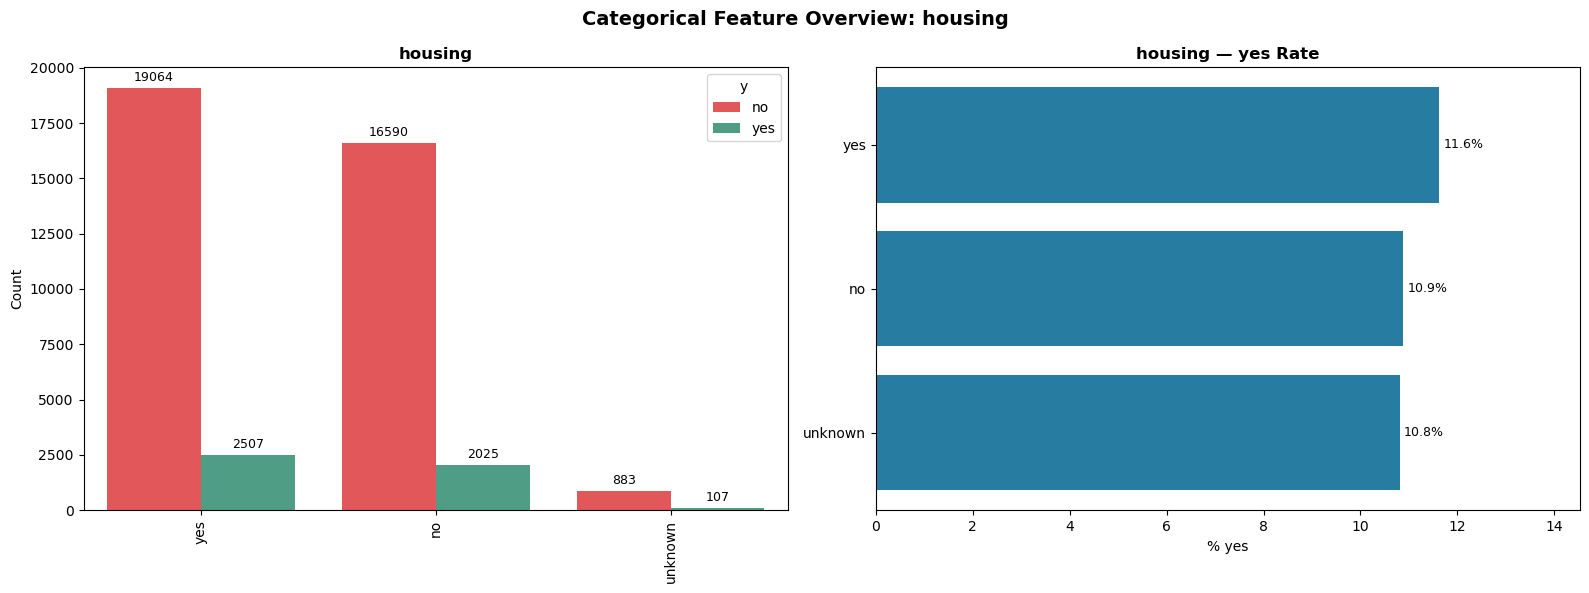

In [39]:
plot_category_overview(
    df=df,
    col=cat_cols[4],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Subscriptions within this column have approximately the same rate, so this column is not informative on its own. Perhaps after analyzing all categorical columns, I will find some other solution, but for now, this is a candidate for removal from the dataset.

### Analysis of the 'loan' column

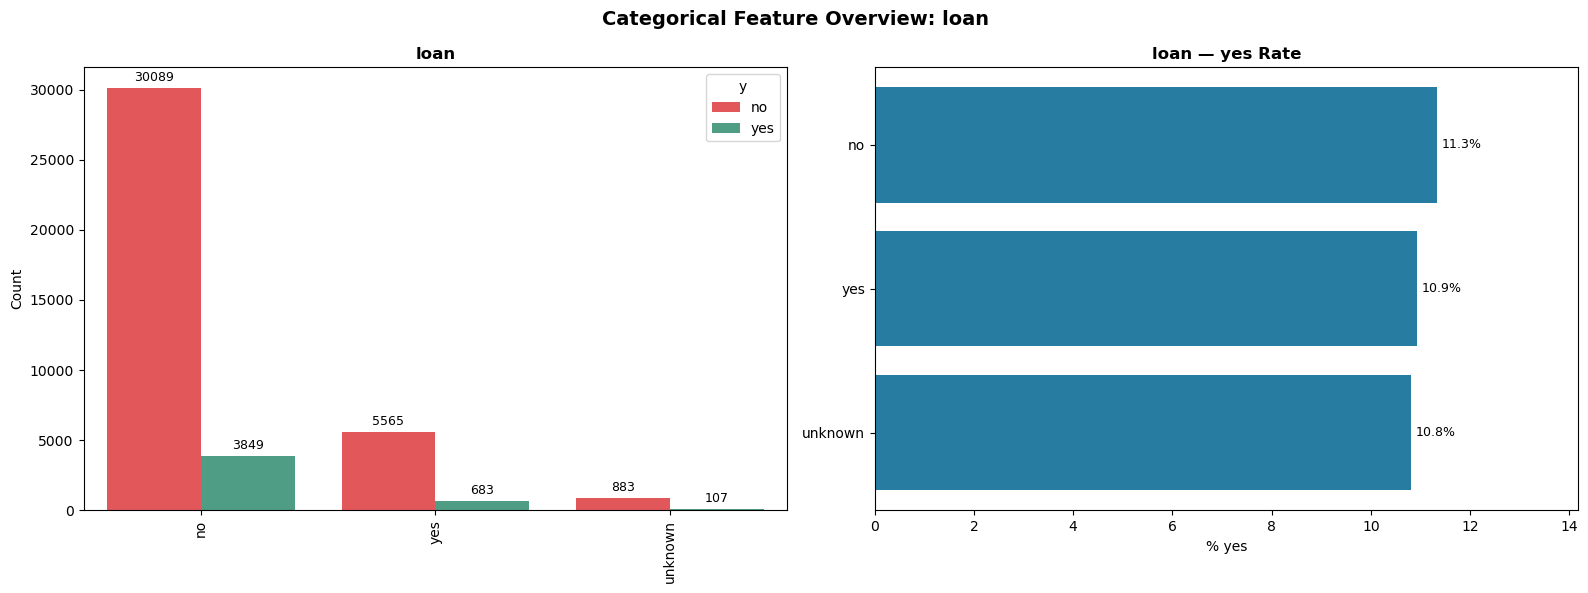

In [42]:
plot_category_overview(
    df=df,
    col=cat_cols[5],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The situation with the non-informativeness of the rate of this column is identical to the 'housing' column. Moreover, these columns are quite similar in value, and it is worth trying to combine them.

In [44]:
df["has_any_loan"] = np.where(
    (df["housing"] == "yes") | (df["loan"] == "yes"), "yes",
    np.where(
        (df["housing"] == "no") | (df["loan"] == "no"), "no",
        "unknown"
    )
)

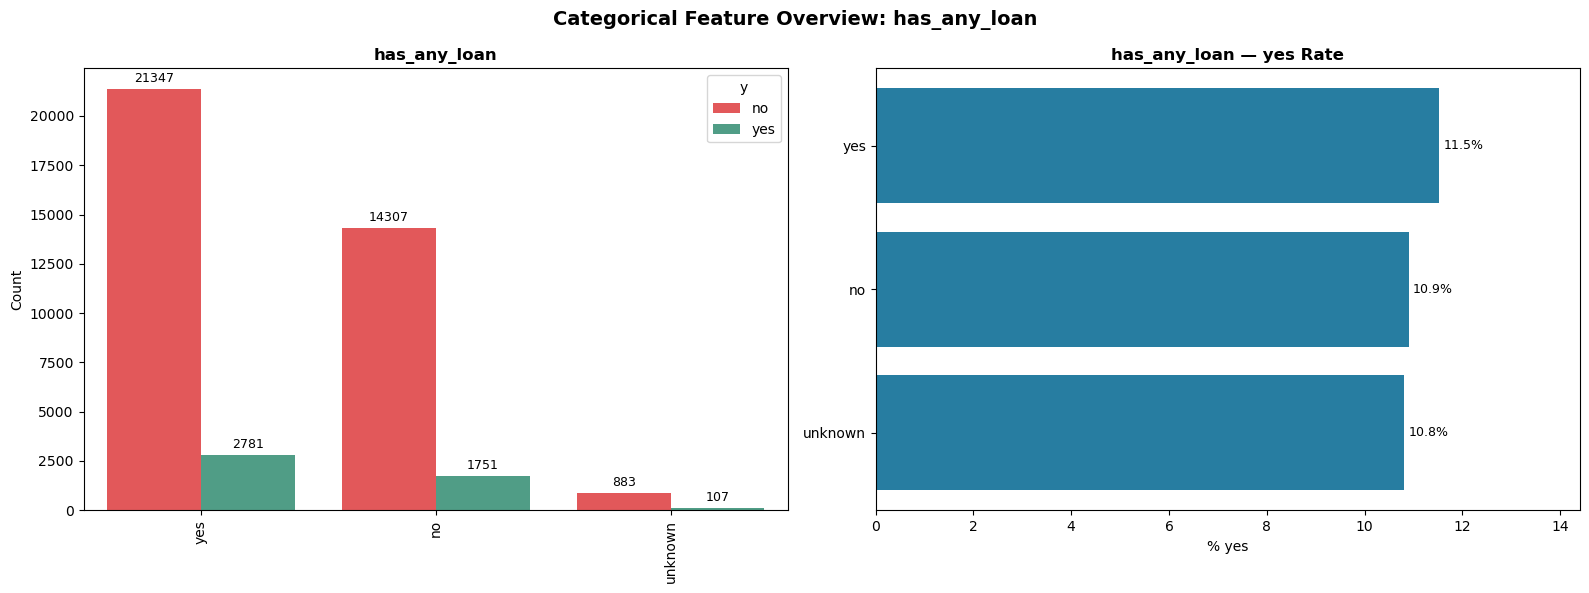

In [45]:
plot_category_overview(
    df=df,
    col='has_any_loan',
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The informativeness of the columns after combining has changed little, so the columns housing and loan will be removed.

### Analysis of the 'contact' column

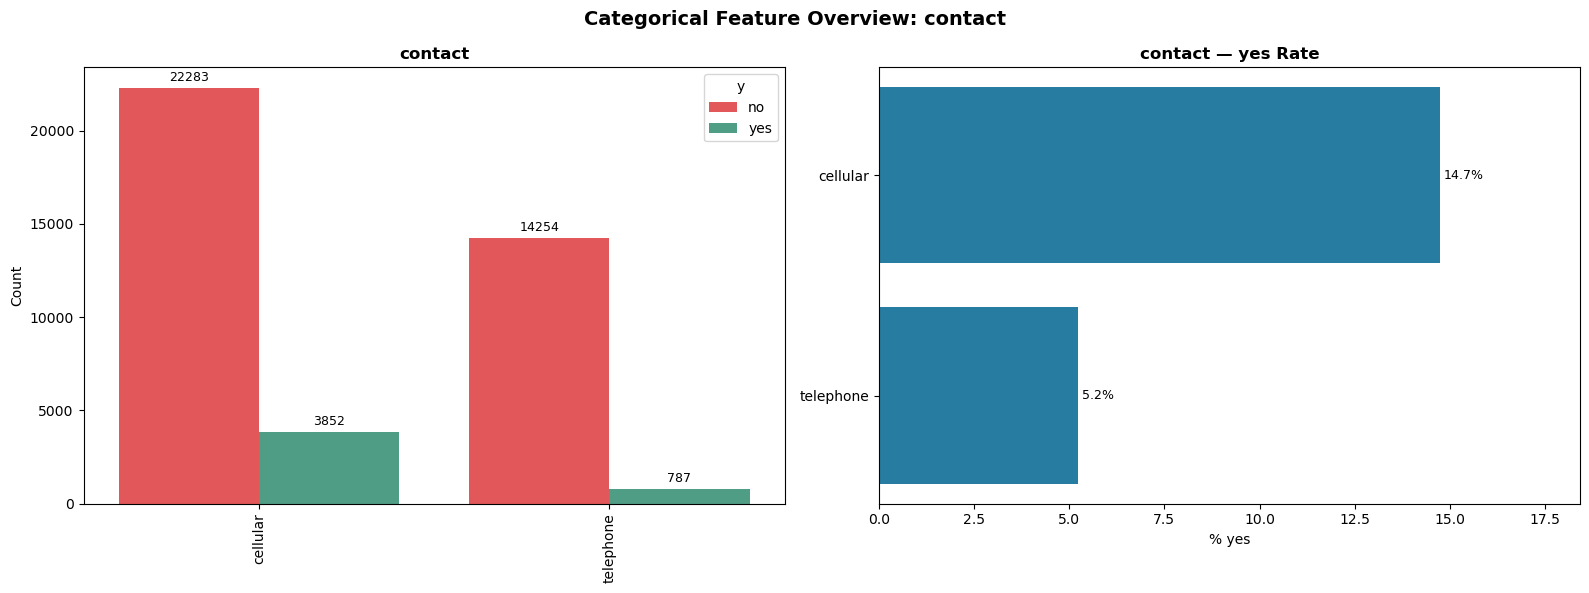

In [48]:
plot_category_overview(
    df=df,
    col=cat_cols[6],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Contact through cellular has a significantly higher positive rate (14.7%) compared to telephone (5.2%), meaning the difference is almost 3 times. At the same time, both categories are represented by a large number of observations, which makes this result reliable for future predictions.

### Analysis of the 'month' column

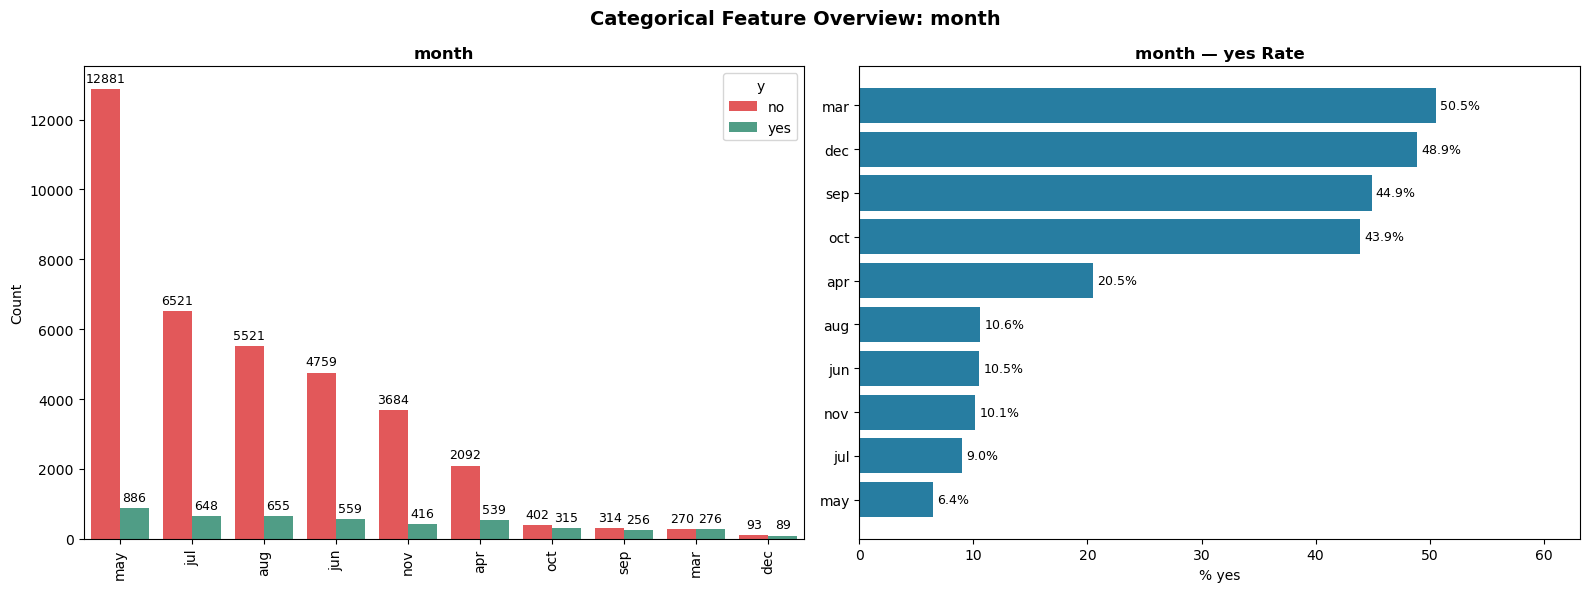

In [51]:
plot_category_overview(
    df=df,
    col=cat_cols[7],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

It is noticeable that most columns with a higher count have a lower rate. It is also possible to try creating a new categorical column based on periods with a similar positive rate. For example, jun-aug, sep-oct...

In [53]:
# New categorical column for months
df["period"] = np.where(
    (df["month"] == "jun") | (df["month"] == "jul") | (df["month"] == "aug"), "jun-aug",
    np.where((df["month"] == "sep") | (df["month"] == "oct"), "sep-oct",
             np.where((df["month"] == "dec") | (df["month"] == "mar"), "dec-mar",
                      df["month"]
                     )
            )
)

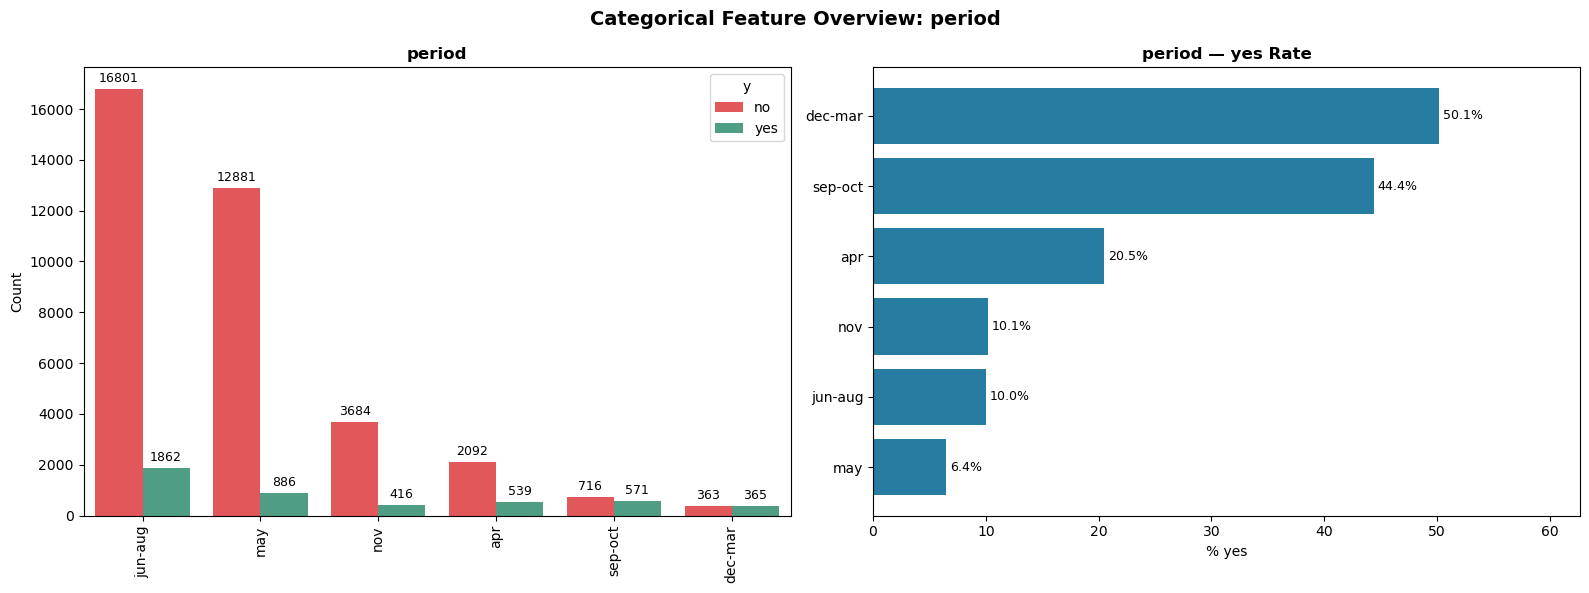

In [54]:
# Display statistics for the new column
plot_category_overview(
    df=df,
    col='period',
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

### Analysis of the 'day_of_week' column

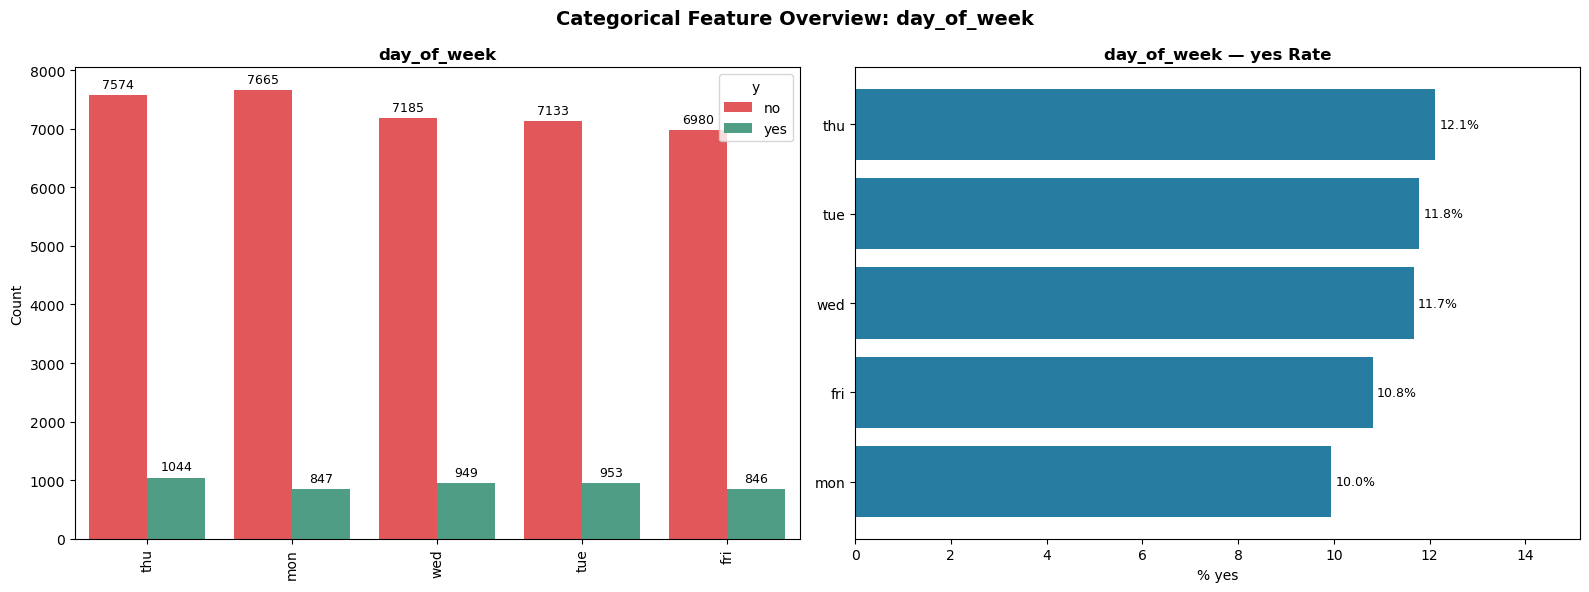

In [56]:
plot_category_overview(
    df=df,
    col=cat_cols[8],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The data is almost evenly distributed across the days. Also, despite a slight dip in the rate on Monday and Friday, it is unlikely to help improve future forecasts, so this column will be removed.

### Analysis of the 'poutcome' column

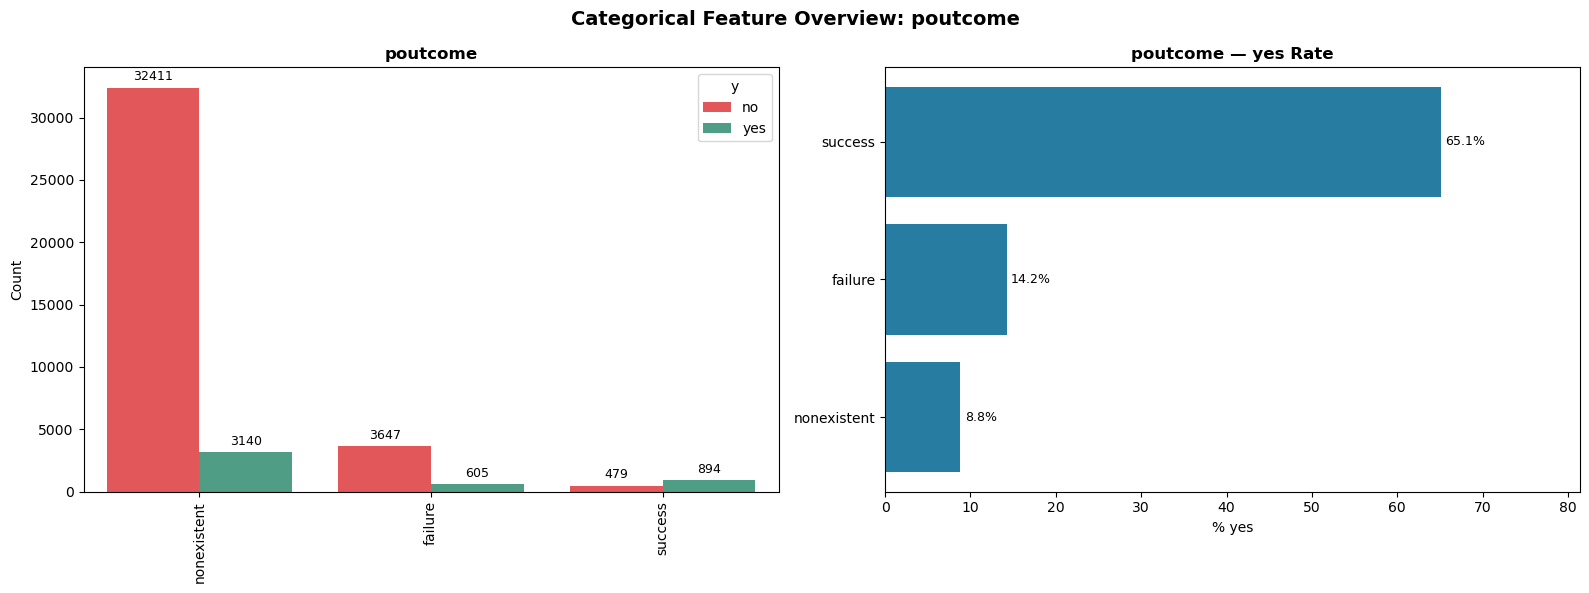

In [59]:
plot_category_overview(
    df=df,
    col=cat_cols[9],
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The success category has an extremely high positive rate, significantly exceeding the values for failure and nonexistent. This is quite understandable, as the result of the previous marketing campaign has a logical impact on the target variable.

# Removing unnecessary categorical columns

In [62]:
df.drop(['default', 'housing', 'loan', 'month', 'day_of_week', 'has_any_loan'], axis=1, inplace=True) 
df.head()

,age,job,marital,education,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,period
0,56,housemaid,not_single,basic.4y,telephone,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,may
1,57,services,not_single,high.school,telephone,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,may
2,37,services,not_single,high.school,telephone,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,may
3,40,admin.,not_single,basic.6y,telephone,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,may
4,56,services,not_single,high.school,telephone,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,may


In [63]:
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols.remove('y')
cat_cols

['job', 'marital', 'education', 'contact', 'poutcome', 'period']

# Analysis of Numerical Variables

In [65]:
# Checking the number of numerical variables
num_cols = df.select_dtypes(include="number").columns
print('Number of numerical variables:', len(num_cols))

Number of numerical variables: 10


Let's display the statistical report for numerical variables.

In [67]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,258.32,2.57,962.46,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.42,259.31,2.77,186.94,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


The data immediately shows the presence of outliers in the first three columns, a small number of non-zero values in the 'previous' column, which requires further analysis.

In [69]:
# I will create a function for processing numerical columns
import warnings

def dist_box(dataset, 
             column,
             target_col: str,
             palette: dict | list | None = None):
    
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.kdeplot(data=dataset,
                  x=column,
                  hue=target_col,
                  linewidth=2,
                  palette=palette,
                  common_norm=False)
      pltname = 'Distribution plot for ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(data = dataset, x=target_col, y = column, palette=palette, flierprops = red_diamond)
      pltname = 'Boxplot for ' + column
      plt.title(pltname)

      plt.show()

### Analysis of the 'age' column

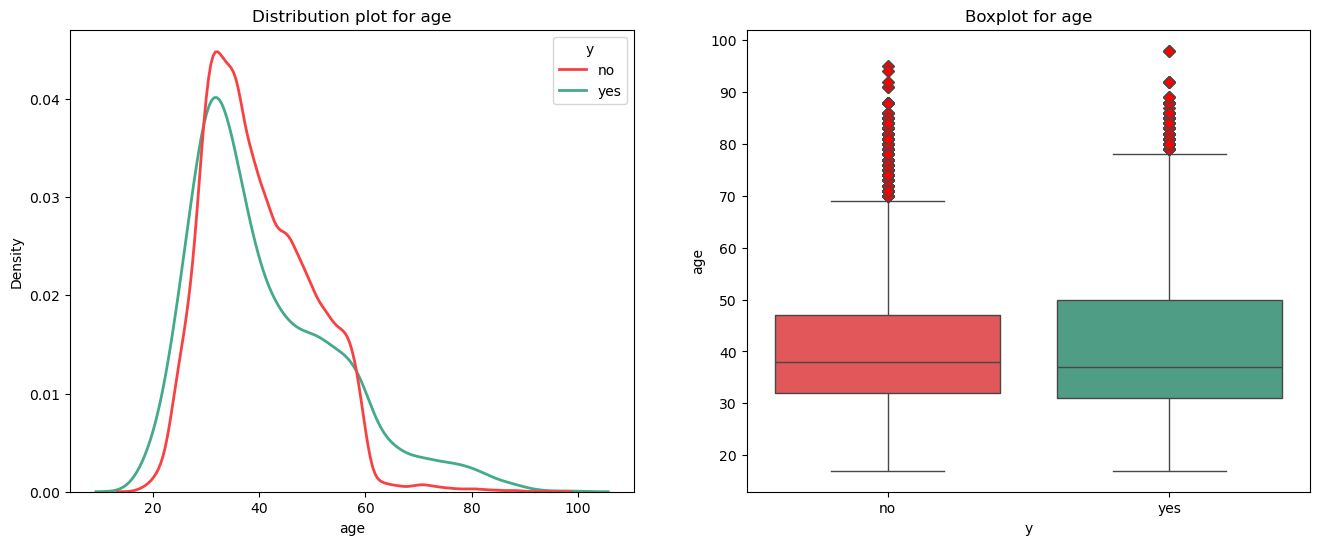

In [71]:
dist_box(df, num_cols[0], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

The graphs show that the target variable has a clear distribution within age categories, with clients under 20 and over 60 having a higher likelihood of signing a term deposit, so I would try to categorize this column.

Also, the boxplot shows that clients over 70 are outliers relative to the main data distribution, so I would treat this category as separate to understand its behavior.

In [73]:
# Function to create age groups
def age_cat(years):
    if years <= 20:
        return '0-20'
    elif years > 20 and years <= 30:
        return '20-30'
    elif years > 30 and years <= 40:
        return '30-40'
    elif years > 40 and years <= 50:
        return '40-50'
    elif years > 50 and years <= 60:
        return '50-60'
    elif years > 60 and years <= 70:
        return '60-70'
    elif years > 70:
        return '70+'

In [74]:
df['age_category'] = df['age'].apply(age_cat)

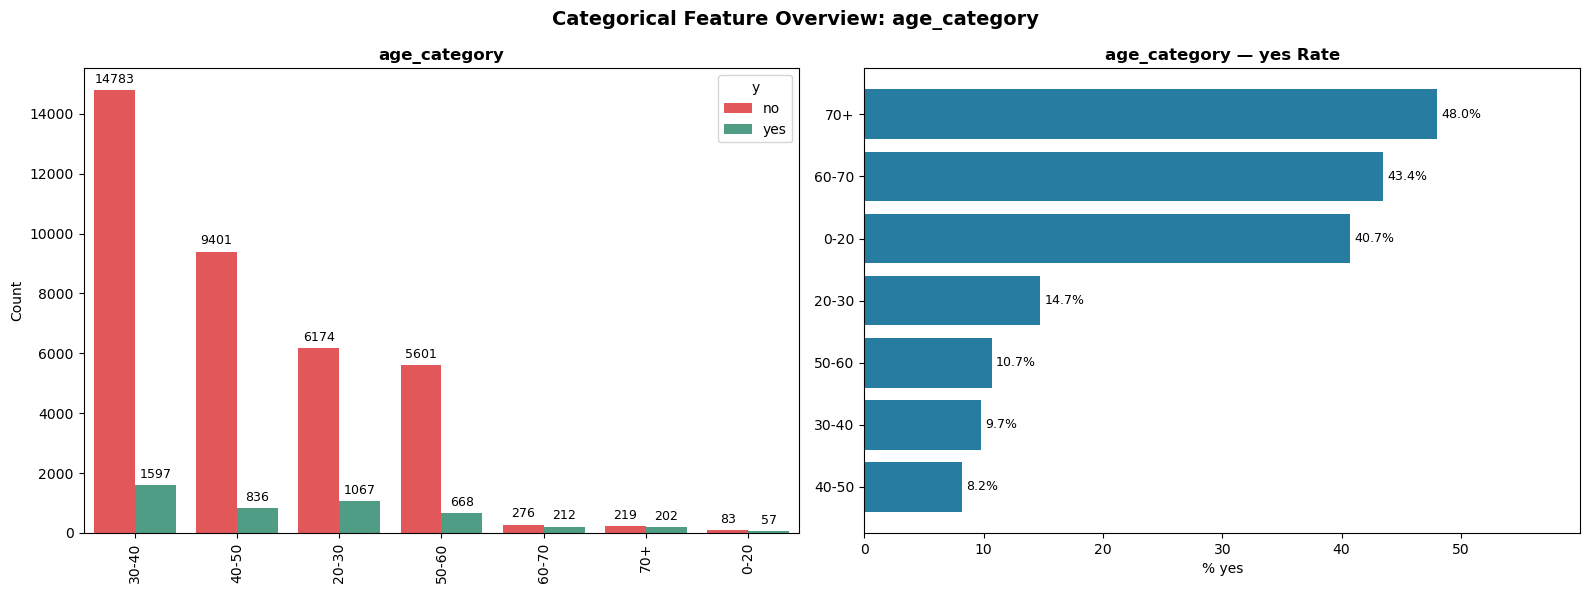

In [75]:
plot_category_overview(
    df=df,
    col='age_category',
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

So, the new customer category is performing very well. Customers in the categories 60-70, 70+, and 0-20 have a significantly lower count compared to other categories, but their positive rate is also significantly higher.

### Analysis of the 'duration' column

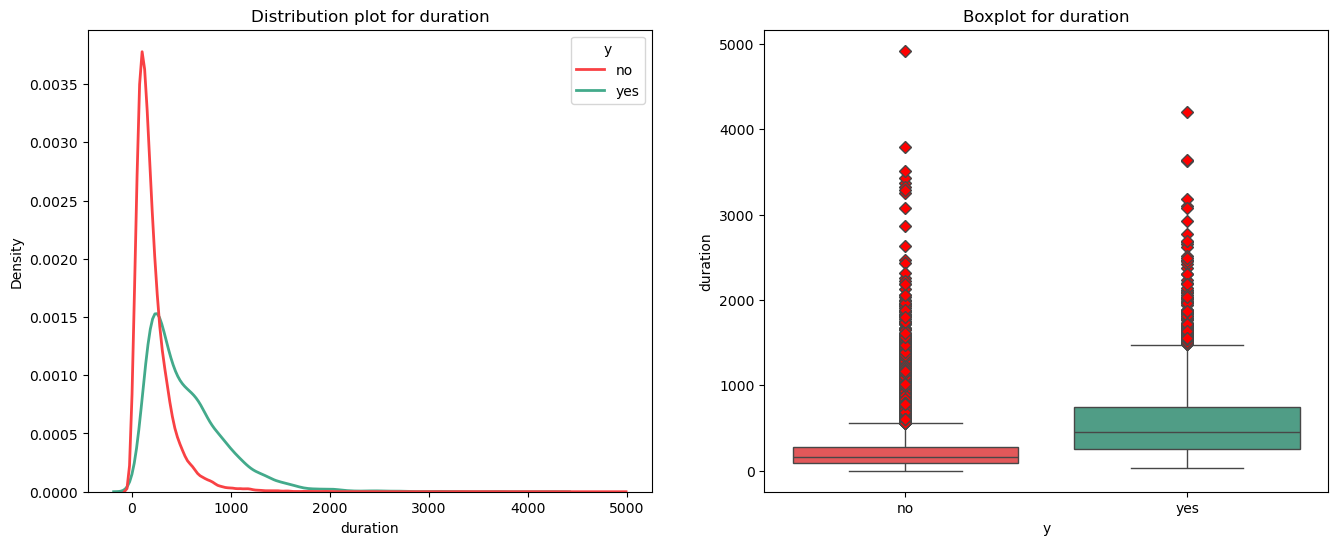

In [78]:
dist_box(df, num_cols[1], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

The graphs clearly show that a larger duration has a significant impact on the target variable. However, Kaggle states the following about this column:

**duration** : last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

In other words, it is better to remove this column in order to create a model in the future that will perform well on new data.

### Analysis of the 'campaign' column

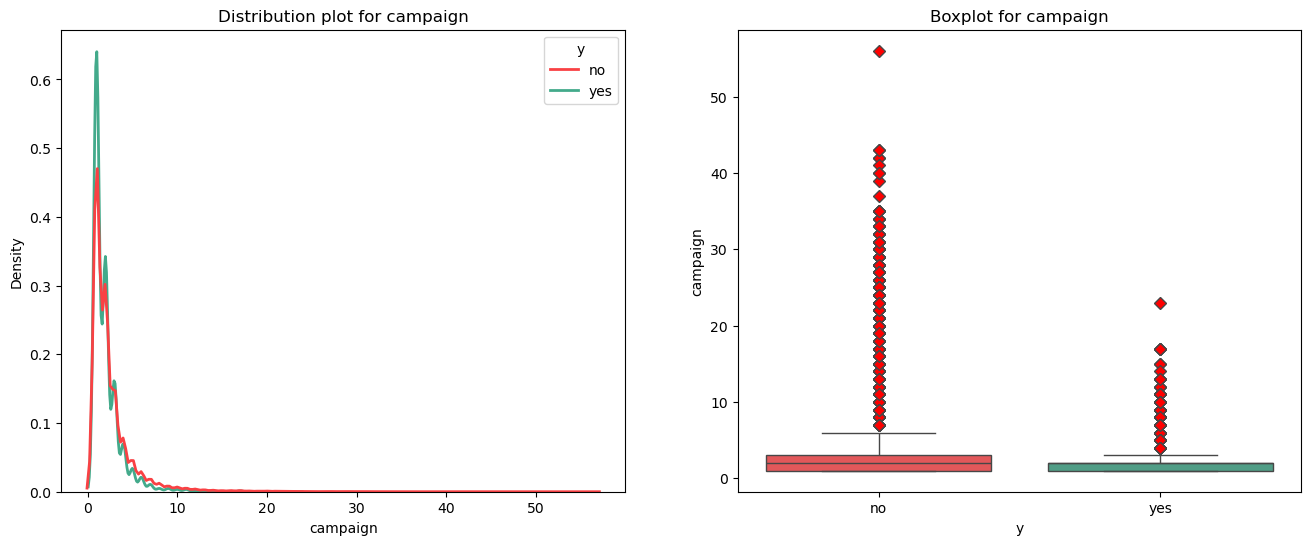

In [81]:
dist_box(df, num_cols[2], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

This column has quite obvious outliers that stand out significantly from the overall picture. Let's analyze them in more detail.

In [83]:
display(df[num_cols[2]].describe(percentiles = [0.75, 0.99, 0.999 ,0.9999]))

count    41176.00
mean         2.57
std          2.77
min          1.00
50%          2.00
75%          3.00
99%         14.00
99.9%       29.00
99.99%      41.88
max         56.00
Name: campaign, dtype: float64

The distribution of the variable is characterized by a strong right skew: most values are concentrated in the lower range (median = 2, 75th percentile = 3), while the 99th percentile = 14, and the maximum = 56.

This indicates the presence of a significant number of outliers that may affect the stability of the model.

Let's analyze the distribution of the data below the 99th percentile.

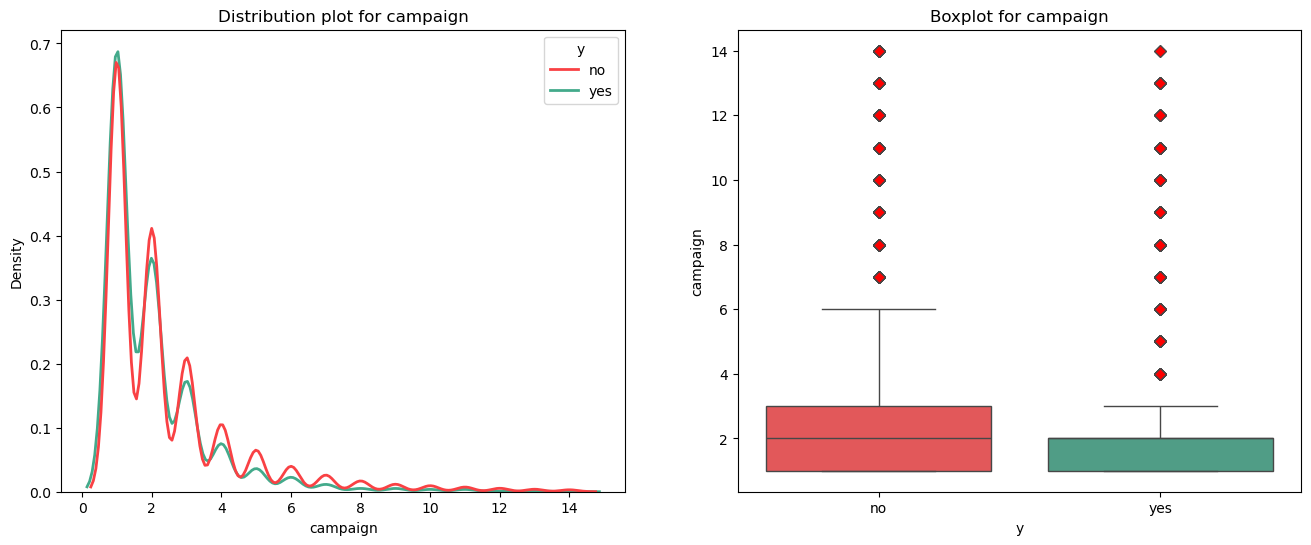

In [85]:
dist_box(df[df[num_cols[2]]<=14], num_cols[2], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

So, after filtering the data above the 99th percentile, we can clearly see the distribution and range of the data on both graphs, excluding only 1% of the data. Therefore, the next step is to remove the data above the 99th percentile from the dataframe.

In [87]:
df = df[df[num_cols[2]]<=14].reset_index(drop=True)  # Filter the DataFrame to keep rows where the value in the third numerical column is less than or equal to 14 and reset the index.

### Analysis of the 'pdays' column

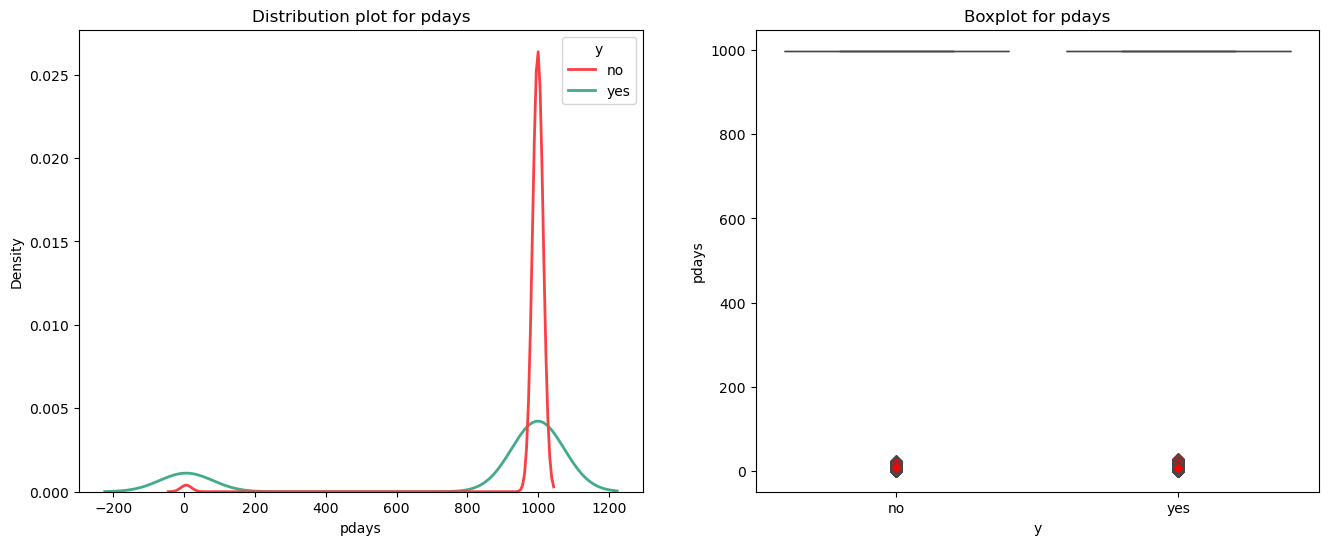

In [89]:
dist_box(df, num_cols[3], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

In the data, we see an extremely high number of rows with the value 999, which means that the client has not been contacted before. Let's analyze the data in the lower percentiles.

In [91]:
display(df[num_cols[3]].describe(percentiles = [0.001, 0.01, 0.05, 0.25, 0.75]))

count   40770.00
mean      962.10
std       187.83
min         0.00
0.1%        1.77
1%          3.00
5%        999.00
25%       999.00
50%       999.00
75%       999.00
max       999.00
Name: pdays, dtype: float64

So, the clients who were previously contacted make up less than 5% of the data, which is quite a significant indicator. Let's check how the data is distributed for clients with prior contact.

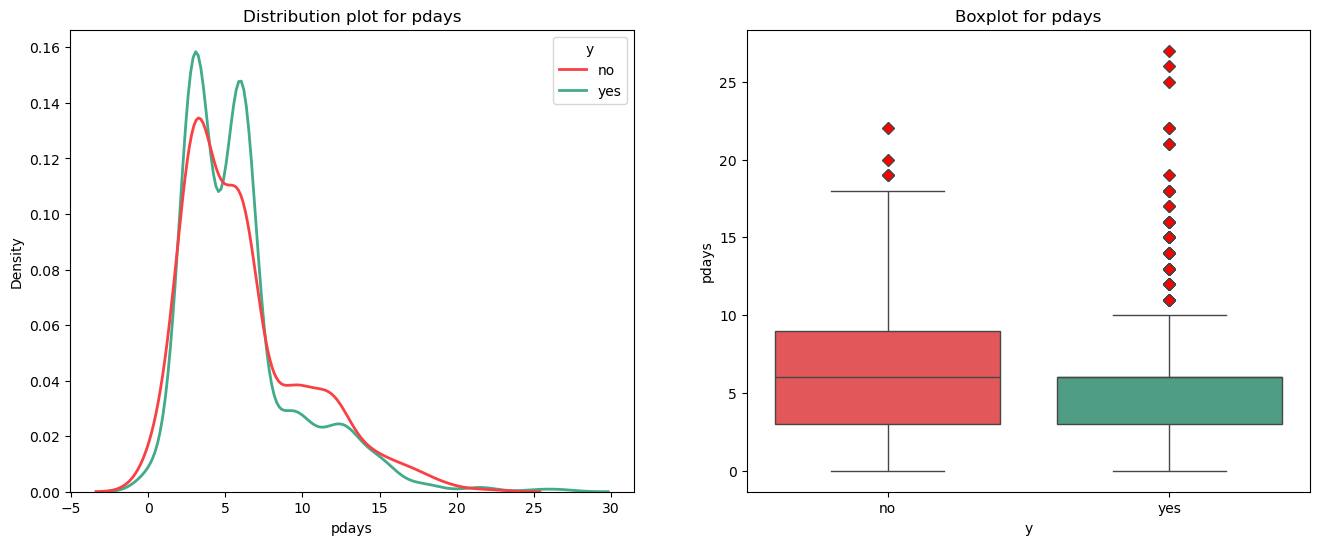

In [93]:
dist_box(df[df[num_cols[3]]<999], num_cols[3], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

So, due to the fact that one indicator occupies the largest share of the data, I do not consider it appropriate to keep the column in its current form.

I will try to create a categorical column based on it and look at the distribution of the target.

In [95]:
df['contacted_before'] = (df['pdays'] != 999).map({True: 'yes', False: 'no'})

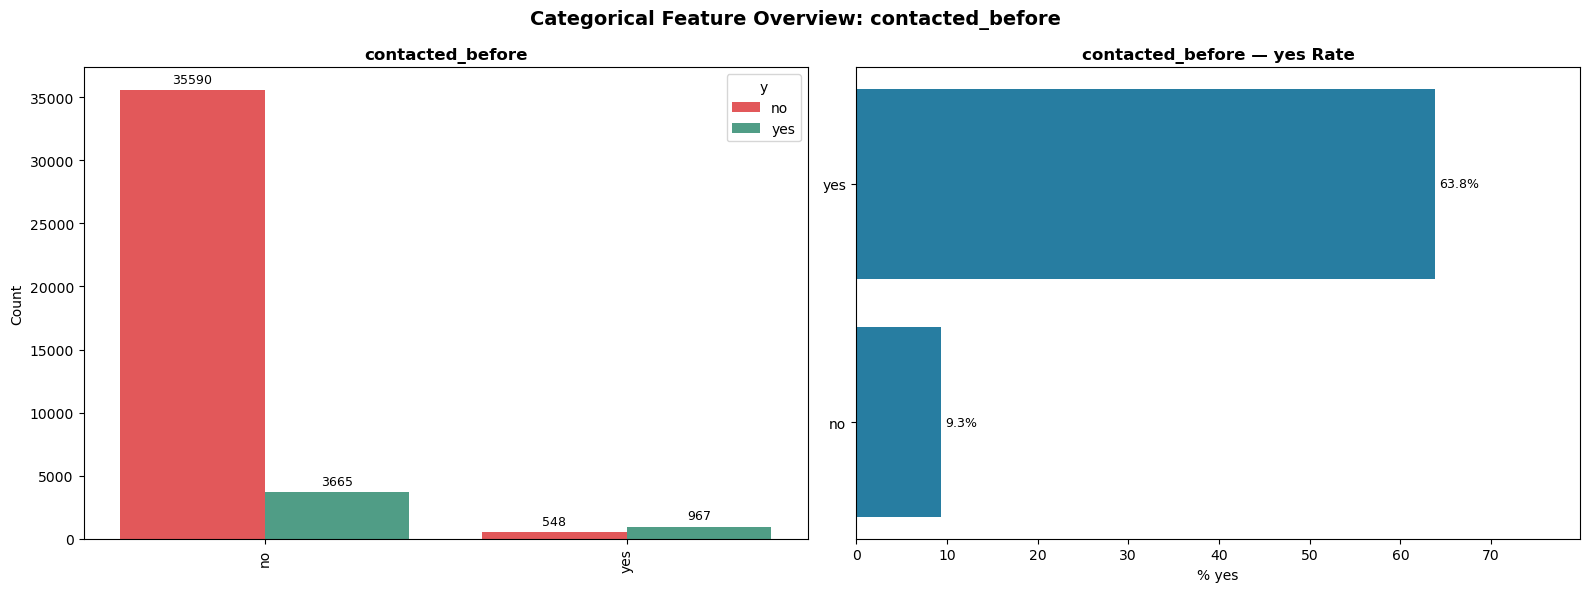

In [96]:
plot_category_overview(
    df=df,
    col='contacted_before',
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

The categorical column created based on pdays has significantly more informative value: almost 64% of clients who had previous contact signed a term deposit. In contrast, clients without contact did so only in 9% of cases.

Therefore, pdays will be removed at the end of the numerical column analysis.

### Analysis of the 'previous' column

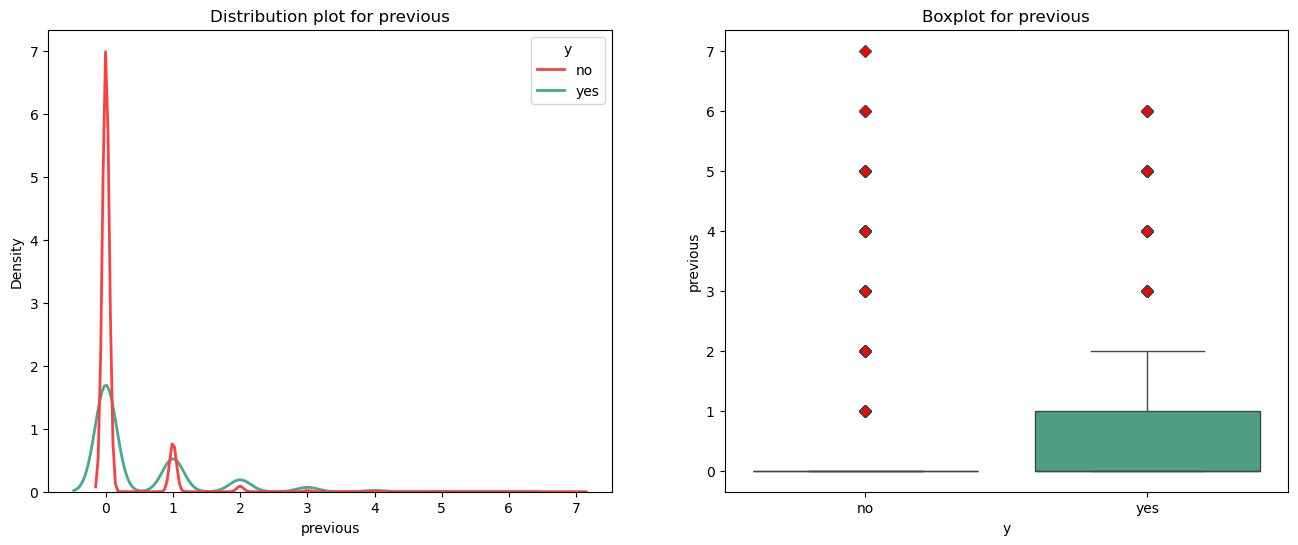

In [99]:
dist_box(df, num_cols[4], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

In this column, there is again a noticeable presence of many clients without prior contact, which has the same informativeness as the newly created column contacted_before.

Let's check how much the data in these columns match.

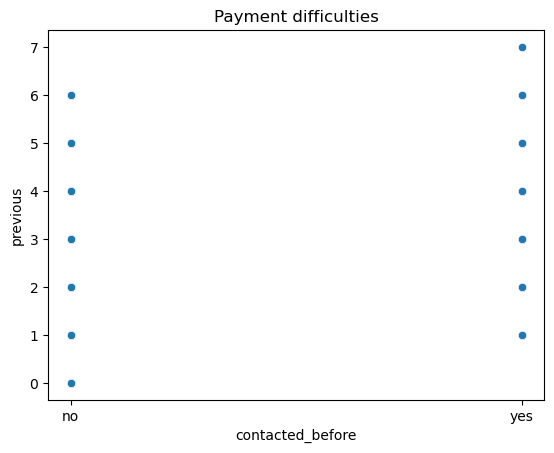

In [101]:
plt.title('Payment difficulties')
sns.scatterplot(x = df['contacted_before'],
                y = df[num_cols[4]], data = df);

The graph shows that there are clients with a contacted_before value of no, who have more than 0 previous contacts. This most likely indicates that the contacts occurred significantly more than 999 days ago.

I will check how many such clients are in our dataset.

In [103]:
df[(df['contacted_before'] == 'no') & (df[num_cols[4]] > 0)].shape

(4108, 19)

So, in the dataset, there are 4108 clients who were contacted more than 999 days ago.

Since the values in the columns contacted_before and previous are related, I have decided to combine them into one.

In [105]:
# First, let's check the distribution of values in the previous column in percentiles
display(df[num_cols[4]].describe(percentiles = [0.75, 0.99, 0.999 ,0.9999]))

count    40770.00
mean         0.17
std          0.50
min          0.00
50%          0.00
75%          0.00
99%          2.00
99.9%        4.00
99.99%       6.00
max          7.00
Name: previous, dtype: float64

We see that more than 2 contacts were only in 1% of clients, so all values greater than that can be grouped into one.

In [107]:
df["contacted_before"] = np.where(
    (df["previous"] > 0) & (df["contacted_before"] == 'no'), 'contacted_long_time_ago',
    np.where((df["previous"] == 0), "not_contacted",
    np.where((df["previous"] == 1), "1_time",
             "2+times"
            )
            )
)

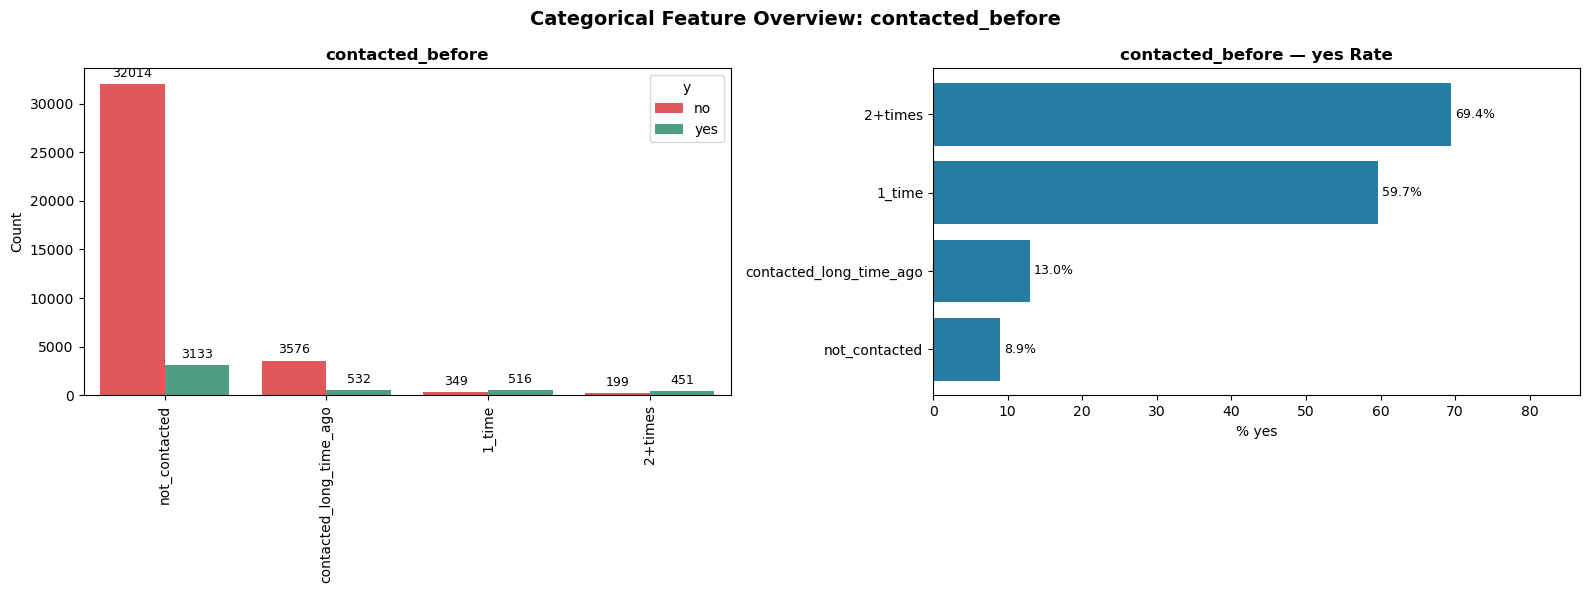

In [108]:
# Build an updated distribution plot of the target by the column contacted_before.

plot_category_overview(
    df=df,
    col='contacted_before',
    target_col='y',
    positive_class='yes',
    hue_order=['no', 'yes'],
    palette={'yes': '#43aa8b', 'no': '#f94144'}
)

Thus, the presence of recent contact with the client has a significant impact on the target value, which is extremely logical. The updated column contacted_before is very informative, and the numerical columns pdays and previous can now be removed.

### Deeper analysis of the new column 'contacted_before'

I consider it appropriate to review how the values of the new column relate to the results of the marketing campaigns, as these columns may be strongly correlated.

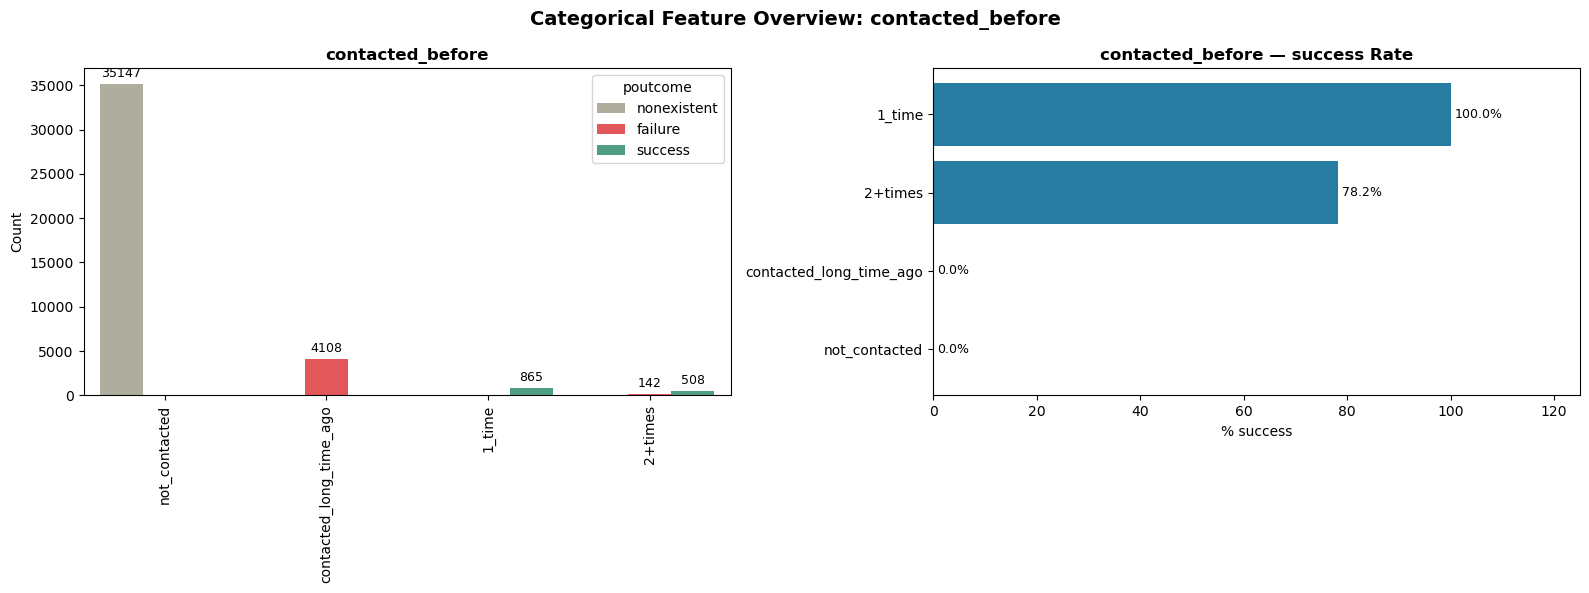

In [112]:
# We will build a graph displaying poutcome instead of the target
plot_category_overview(
    df=df,
    col='contacted_before',
    target_col='poutcome',
    positive_class='success',
    hue_order=['nonexistent', 'failure', 'success'],
    palette={'success':'#43aa8b', 'failure':'#f94144', 'nonexistent': '#b2b09b'}
)

So, from the graph, it is clear that these 2 categorical columns are not just related, but show the same information. For example, the values 'not_contacted' and 'contacted_long_time_ago' are equal to the values 'nonexistment' and 'failure'. Therefore, the column 'poutcome' will be removed at the end of the numerical column analysis.

### Analysis of the 'emp.var.rate' column

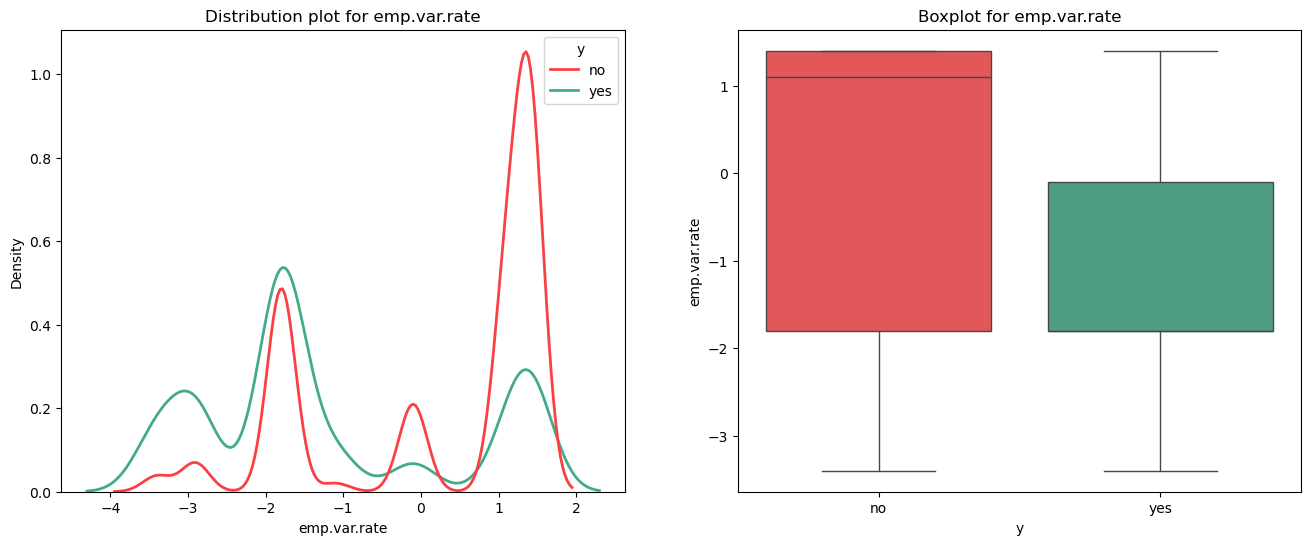

In [115]:
dist_box(df, num_cols[5], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

The graphs clearly show that when the rate of change in employment is negative, clients are more likely to sign a term deposit.

### Analysis of the 'cons.price.idx' column

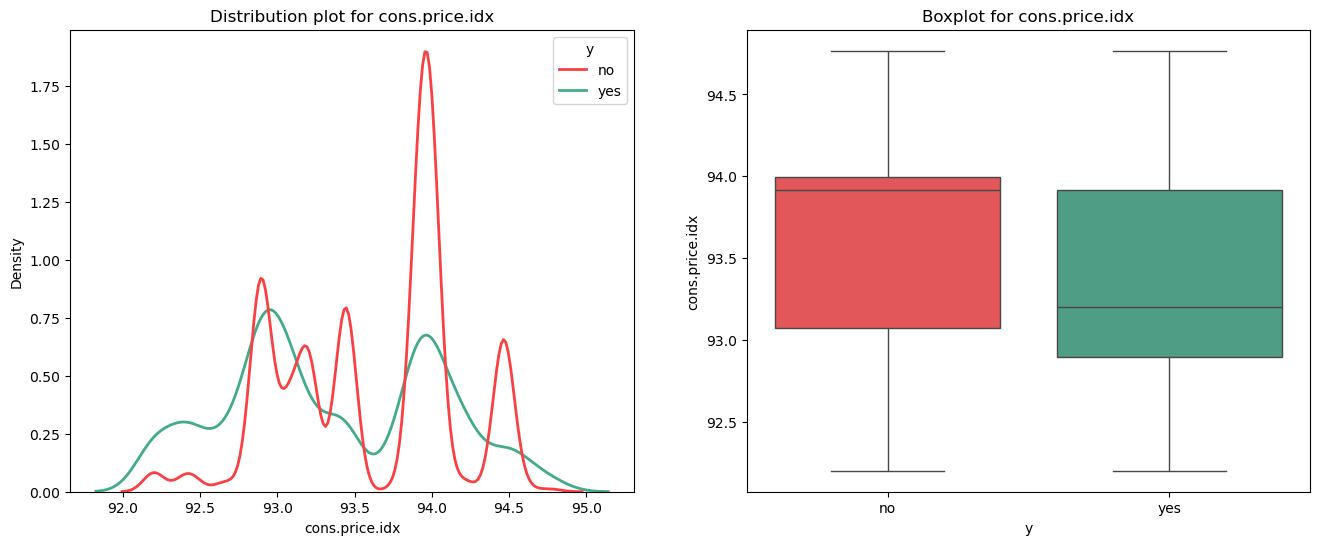

In [118]:
dist_box(df, num_cols[6], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

The variable cons.price.idx does not show a clear separation between classes: the distributions for yes and no largely overlap. Thus, the feature has limited informativeness and is likely not a strong predictor of the target variable.

### Analysis of the 'cons.conf.idx' column

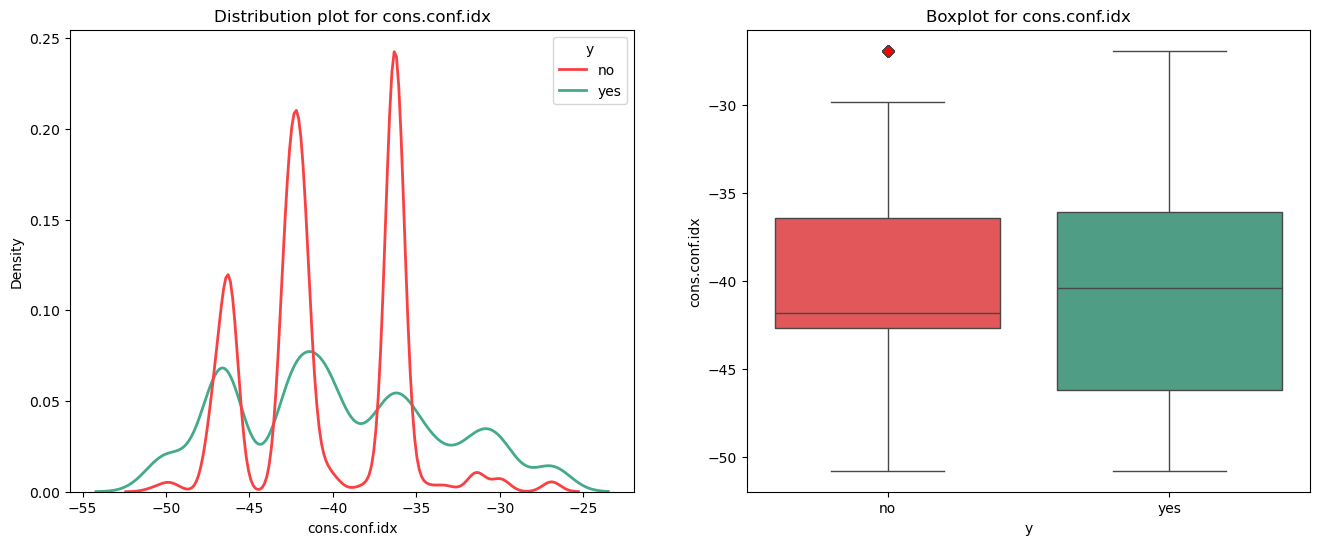

In [121]:
dist_box(df, num_cols[7], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

From the graph, it can be concluded that the group "yes" has less negative values, but it is difficult to judge the informativeness of this column for the future model.

### Analysis of the 'euribor3m' column

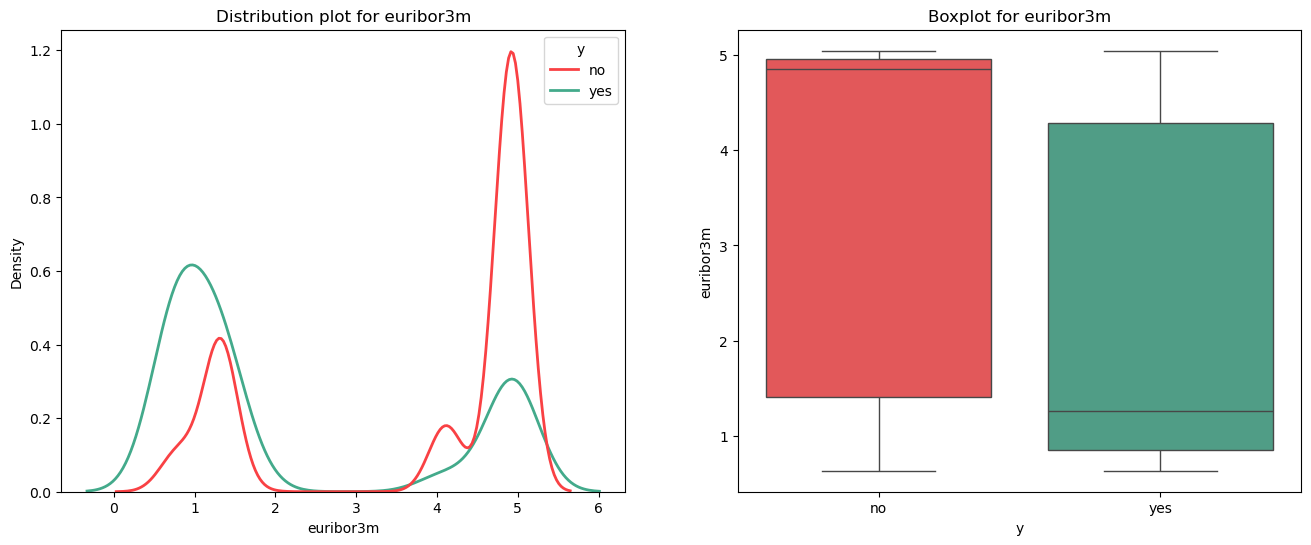

In [124]:
dist_box(df, num_cols[8], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

For the group "no," significantly higher values of the indicator are characteristic, while for "yes," they are mostly lower. Overall, the column appears to be informative for future models.

### Analysis of the 'nr.employed' column

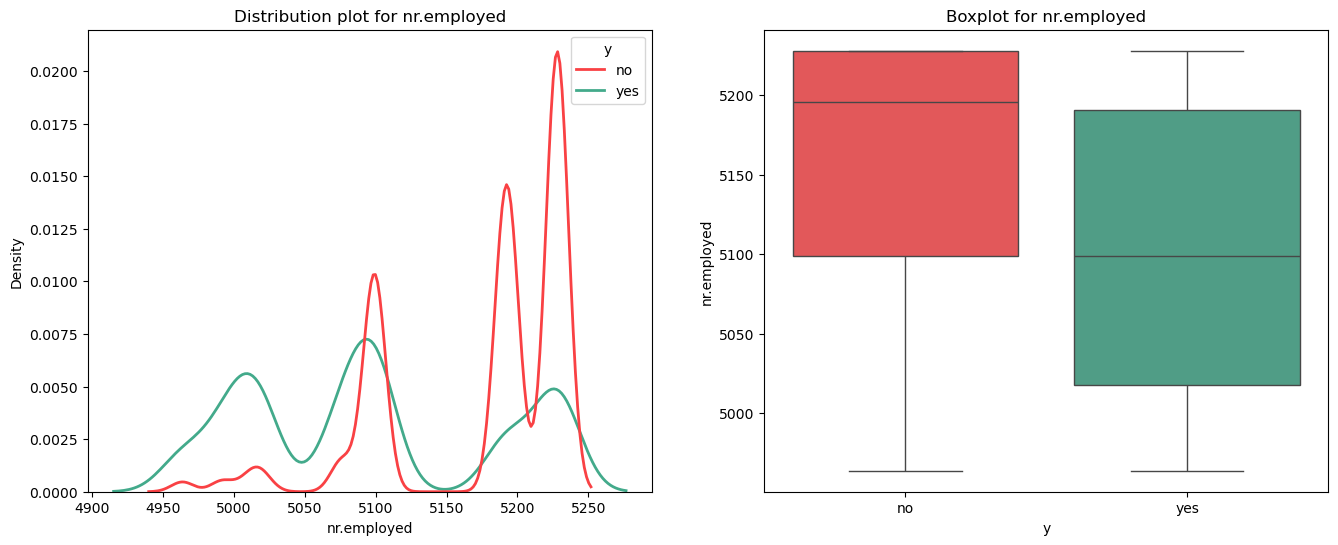

In [127]:
dist_box(df, num_cols[9], target_col='y', palette={'yes': '#43aa8b', 'no': '#f94144'})

For the group "no," higher values of the indicator are characteristic, while for "yes," lower values are typical.

# Removing unnecessary numerical columns

In [130]:
df = df.drop(['age', 'duration', 'pdays', 'previous', 'poutcome'], axis=1)
df.head()

,job,marital,education,contact,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,period,age_category,contacted_before
0,housemaid,not_single,basic.4y,telephone,1,1.10,93.99,-36.40,4.86,5191.00,no,may,50-60,not_contacted
1,services,not_single,high.school,telephone,1,1.10,93.99,-36.40,4.86,5191.00,no,may,50-60,not_contacted
2,services,not_single,high.school,telephone,1,1.10,93.99,-36.40,4.86,5191.00,no,may,30-40,not_contacted
3,admin.,not_single,basic.6y,telephone,1,1.10,93.99,-36.40,4.86,5191.00,no,may,30-40,not_contacted
4,services,not_single,high.school,telephone,1,1.10,93.99,-36.40,4.86,5191.00,no,may,50-60,not_contacted


In [131]:
# Update the list of categorical and numerical variables
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols.remove('y')
num_cols = df.select_dtypes(include="number").columns.tolist()

cat_cols, num_cols

(['job',
  'marital',
  'education',
  'contact',
  'period',
  'age_category',
  'contacted_before'],
 ['campaign',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'])

# Correlation analysis of numerical variables

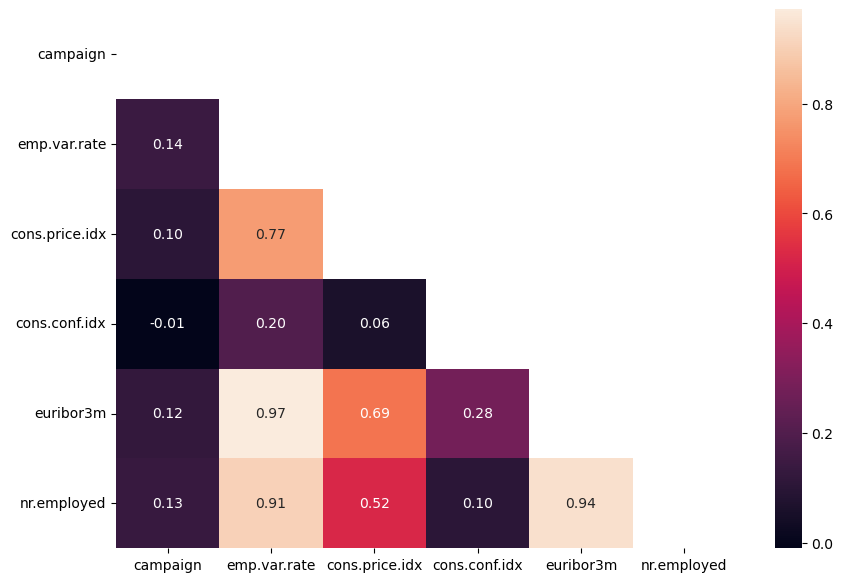

In [133]:
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize = (10,7))
sns.heatmap(data = corr, mask=mask, annot = True, cbar = True, fmt='.2f')
plt.show()

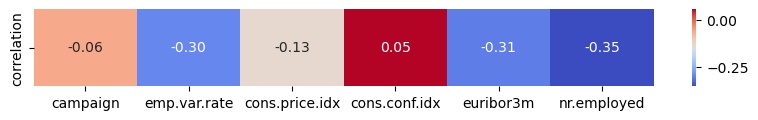

In [134]:
# Correlation with the target
y = (df['y'] == 'yes').astype(int)
correlations = df[num_cols].corrwith(y)

corr_df = correlations.to_frame(name='correlation').T

plt.figure(figsize=(10, 1))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In the correlation matrix, the columns euribor3m, emp.var.rate, and nr.employed have an extremely high correlation with each other (> 90%) and correlate well with the target. Therefore, it is advisable to keep only one column to avoid information duplication and increase the stability of future predictive models.

To make the right choice, I will check the number of values in the numerical columns.

In [136]:
for col in num_cols:
    print(col, df[col].nunique())  # Print the number of unique values for each numerical column

campaign 14
emp.var.rate 10
cons.price.idx 26
cons.conf.idx 26
euribor3m 316
nr.employed 11


The column euribor3m has significantly more values, which is a plus. Therefore, I will keep it.

Also, the feature cons.price.idx has limited informativeness and is not a strong predictor of the target variable. Additionally, it has a 69% correlation with euribor3m. Therefore, I will also remove this column.

In [138]:
df = df.drop(['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed'], axis=1)
df.head()

,job,marital,education,contact,campaign,euribor3m,y,period,age_category,contacted_before
0,housemaid,not_single,basic.4y,telephone,1,4.86,no,may,50-60,not_contacted
1,services,not_single,high.school,telephone,1,4.86,no,may,50-60,not_contacted
2,services,not_single,high.school,telephone,1,4.86,no,may,30-40,not_contacted
3,admin.,not_single,basic.6y,telephone,1,4.86,no,may,30-40,not_contacted
4,services,not_single,high.school,telephone,1,4.86,no,may,50-60,not_contacted


In [139]:
# Update the list of categorical and numerical variables
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols.remove('y')
num_cols = df.select_dtypes(include="number").columns.tolist()

# Preprocessed Data

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

### train_test_split

In [143]:
train_df, test_df = train_test_split(df,
                                    test_size=0.25,
                                    random_state=42,
                                    stratify=df['y'])

In [144]:
target_col = 'y'
input_cols = list(train_df.drop(target_col, axis=1).columns)

In [145]:
input_cols

['job',
 'marital',
 'education',
 'contact',
 'campaign',
 'euribor3m',
 'period',
 'age_category',
 'contacted_before']

In [146]:
train_inputs, train_target = train_df[input_cols], train_df[target_col]
test_inputs, test_target = test_df[input_cols], test_df[target_col]

In [147]:
train_target = (train_target == 'yes').astype(int)  
test_target = (test_target == 'yes').astype(int)  

### Scaling Numerical Features

In [149]:
scaler = StandardScaler()
#scaler = MinMaxScaler()
scaler.fit(train_inputs[num_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [150]:
train_inputs[num_cols] = scaler.transform(train_inputs[num_cols])
test_inputs[num_cols] = scaler.transform(test_inputs[num_cols])

train_inputs[num_cols].describe().round(2)

/var/folders/vq/w1vp6s4d343cmmrh0lp122280000gn/T/ipykernel_3108/2827489490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs[num_cols] = scaler.transform(train_inputs[num_cols])
/var/folders/vq/w1vp6s4d343cmmrh0lp122280000gn/T/ipykernel_3108/2827489490.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_inputs[num_cols] = scaler.transform(test_inputs[num_cols])


,campaign,euribor3m
count,30577.00,30577.00
mean,0.00,0.00
std,1.00,1.00
min,-0.69,-1.71
25%,-0.69,-1.30
50%,-0.19,0.72
75%,0.31,0.78
max,5.80,0.83


### Encoding Categorical Columns

In [152]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[cat_cols])
encoder.categories_

[array(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
        'retired', 'self-employed', 'services', 'student', 'technician',
        'unemployed', 'unknown'], dtype=object),
 array(['not_single', 'single'], dtype=object),
 array(['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate',
        'professional.course', 'university.degree', 'unknown'],
       dtype=object),
 array(['cellular', 'telephone'], dtype=object),
 array(['apr', 'dec-mar', 'jun-aug', 'may', 'nov', 'sep-oct'], dtype=object),
 array(['0-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+'],
       dtype=object),
 array(['1_time', '2+times', 'contacted_long_time_ago', 'not_contacted'],
       dtype=object)]

In [153]:
encoded_cols = list(encoder.get_feature_names_out(cat_cols))
print(encoded_cols)

['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_not_single', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'contact_cellular', 'contact_telephone', 'period_apr', 'period_dec-mar', 'period_jun-aug', 'period_may', 'period_nov', 'period_sep-oct', 'age_category_0-20', 'age_category_20-30', 'age_category_30-40', 'age_category_40-50', 'age_category_50-60', 'age_category_60-70', 'age_category_70+', 'contacted_before_1_time', 'contacted_before_2+times', 'contacted_before_contacted_long_time_ago', 'contacted_before_not_contacted']


In [154]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[cat_cols])  # Преобразування категоріальних ознак для навчальних даних
test_inputs[encoded_cols] = encoder.transform(test_inputs[cat_cols])  # Преобразування категоріальних ознак для тестових даних

In [155]:
# I will check if there are columns in cat_cols with only two values.
df[cat_cols].nunique()

job                 12
marital              2
education            8
contact              2
period               6
age_category         7
contacted_before     4
dtype: int64

In the dataframe, there are two columns (marital and contact) that after OneHotEncoder created 2 additional columns with already existing information, which will not be useful for predictive models. Therefore, the additional columns will be removed from train_inputs and test_inputs. In addition, the categorical columns based on which the encoding was performed will also be removed.

In [157]:
# Removing unnecessary columns from inputs
for col in ['marital_not_single', 'contact_telephone']:
    if col in encoded_cols:
        encoded_cols.remove(col)

train_inputs.drop(columns=cat_cols, inplace=True)
test_inputs.drop(columns=cat_cols, inplace=True)
train_inputs.drop(['marital_not_single', 'contact_telephone'], axis=1, inplace=True)
test_inputs.drop(['marital_not_single', 'contact_telephone'], axis=1, inplace=True)

# Predictive Models

In [159]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import lightgbm as lgb
from hyperopt.early_stop import no_progress_loss

/opt/anaconda3/lib/python3.11/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [160]:
X_train = train_inputs[num_cols + encoded_cols].copy()
test_inputs = test_inputs[num_cols + encoded_cols].copy()

### Function for comparing models

In [162]:
def evaluate(model, X_train, train_target, test_inputs, test_target, name='Model'):
    """Повертає словник ключових метрик для навчальних та тестових наборів."""
    results = {}
    for split, X, y in [('train', X_train, train_target), ('test', test_inputs, test_target)]:
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
        results[split] = {
            'accuracy' : accuracy_score(y, y_pred),
            'precision': precision_score(y, y_pred),
            'recall'   : recall_score(y, y_pred),
            'f1'       : f1_score(y, y_pred),
            'roc_auc'  : roc_auc_score(y, y_prob) if y_prob is not None else np.nan
        }
    return results

# Save all model results for comparison
all_results = {}

### 1. DummyClassifier with most_frequent strategy

In [164]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, train_target)

print(classification_report(test_target, dummy.predict(test_inputs),
                             target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      9035
         yes       0.00      0.00      0.00      1158

    accuracy                           0.89     10193
   macro avg       0.44      0.50      0.47     10193
weighted avg       0.79      0.89      0.83     10193



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [165]:
all_results['Dummy'] = evaluate(dummy, X_train, train_target, test_inputs, test_target)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 2. LogisticRegression

In [167]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, train_target)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [168]:
y_train_pred = lr.predict(X_train)
test_target_pred = lr.predict(test_inputs)

f1_train = f1_score(train_target, y_train_pred)
f1_test = f1_score(test_target, test_target_pred)

print("Train F1 score:", f1_train)
print("Test F1 score:", f1_test)

Train F1 score: 0.41982774418178487
Test F1 score: 0.4250484898863951


In [169]:
lr.predict_proba(test_inputs)[:, 1]

array([0.61261802, 0.38325465, 0.14371189, ..., 0.51988868, 0.53463036,
       0.7804676 ], shape=(10193,))

In [170]:
print(classification_report(test_target, lr.predict(test_inputs),
                             target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.95      0.81      0.88      9035
         yes       0.31      0.66      0.43      1158

    accuracy                           0.80     10193
   macro avg       0.63      0.74      0.65     10193
weighted avg       0.88      0.80      0.83     10193



In [171]:
all_results['Logistic Regression'] = evaluate(lr, X_train, train_target, test_inputs, test_target)

### 3. K-Nearest Neighbors (KNN)

In [173]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Create a stratified K-Fold cross-validator with 5 splits, shuffling the data and setting a random state for reproducibility.

In [174]:
knn = KNeighborsClassifier()

params_knn = {
    'n_neighbors': np.arange(1, 300, 3)
}

knn_gs = GridSearchCV(
    knn,
    params_knn,
    cv=cv,
    scoring='roc_auc'
)

knn_gs.fit(X_train, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, ...92, 295, 298])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [175]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(289)} 0.7767626135048773


In [176]:
y_train_proba = knn_best.predict_proba(X_train)[:,1]
test_target_proba = knn_best.predict_proba(test_inputs)[:,1]

roc_train = roc_auc_score(train_target, y_train_proba)  # Calculate the ROC AUC score for the training set
roc_test = roc_auc_score(test_target, test_target_proba)  # Calculate the ROC AUC score for the test set

print("Train AUROC:", roc_train)  # Print the AUROC for the training set
print("Test AUROC:", roc_test)  # Print the AUROC for the test set

Train AUROC: 0.792156591230227
Test AUROC: 0.7908141720979532


In [177]:
print(classification_report(test_target, knn_best.predict(test_inputs),
                             target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      9035
         yes       0.68      0.05      0.09      1158

    accuracy                           0.89     10193
   macro avg       0.78      0.52      0.51     10193
weighted avg       0.87      0.89      0.84     10193



In [178]:
all_results['KNN'] = evaluate(knn_gs, X_train, train_target, test_inputs, test_target)

### 4. Decision Tree

In [180]:
dt = DecisionTreeClassifier(class_weight='balanced',
                            random_state=42)
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 50),
    'max_leaf_nodes': np.arange(2, 50),
    'min_samples_split': np.arange(1, 50),
    'min_samples_leaf': np.arange(1, 50),
    'max_features': [None, 'sqrt', 'log2']
}

search = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter = 40,
    cv=cv,
    scoring='roc_auc',
    verbose=0,
    refit=True,
    random_state=42,
    n_jobs=-1 # use all processors and parallelize the search
)
search.fit(X_train, train_target)

/opt/anaconda3/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': array([ 1, 2..., 47, 48, 49]), 'max_features': [None, 'sqrt', ...], 'max_leaf_nodes': array([ 2, 3..., 47, 48, 49]), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [181]:
dt_best = search.best_estimator_
print(dt_best)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=np.int64(34), max_leaf_nodes=np.int64(39),
                       min_samples_leaf=np.int64(27),
                       min_samples_split=np.int64(23), random_state=42)


In [182]:
y_train_proba = dt_best.predict_proba(X_train)[:,1]
test_target_proba = dt_best.predict_proba(test_inputs)[:,1]

roc_train = roc_auc_score(train_target, y_train_proba)  # Calculate the ROC AUC score for the training set
roc_test = roc_auc_score(test_target, test_target_proba)  # Calculate the ROC AUC score for the test set

print("Train AUROC:", roc_train)  # Print the AUROC for the training set
print("Test AUROC:", roc_test)  # Print the AUROC for the test set

Train AUROC: 0.8021229903340443
Test AUROC: 0.8010488858813306


In [183]:
print(classification_report(test_target, knn_gs.predict(test_inputs),
                             target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      9035
         yes       0.68      0.05      0.09      1158

    accuracy                           0.89     10193
   macro avg       0.78      0.52      0.51     10193
weighted avg       0.87      0.89      0.84     10193



In [184]:
all_results['Decision Tree'] = evaluate(dt_best, X_train, train_target, test_inputs, test_target)

### 5. XGBoost + Random search

In [186]:
# Imbalance ratio
neg, pos = (train_target == 0).sum(), (train_target == 1).sum()
scale_pos_weight_min = round(neg / pos / 3, 2)
scale_pos_weight_max = round(neg / pos * 1.5, 2)

scale_pos_weight_min, scale_pos_weight_max

(np.float64(2.6), np.float64(11.7))

In [187]:
# Base model
xgb_clf = xgb.XGBClassifier(
    enable_categorical=True,
    eval_metric='auc',
    missing=np.nan,
    # device='cuda',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Hyperparameter space for random search
param_dist = {
    'n_estimators'    : np.arange(50, 500, 25),          
    'learning_rate'   : np.linspace(0.01, 0.3, 30),      
    'max_depth'       : np.arange(3, 16),                 
    'min_child_weight': np.arange(1, 11),                 
    'subsample'       : np.linspace(0.5, 1.0, 11),       
    'colsample_bytree': np.linspace(0.5, 1.0, 11),       
    'gamma'           : np.linspace(0, 0.5, 11),         
    'reg_alpha'       : np.linspace(0, 1.0, 11),         
    'reg_lambda'      : np.linspace(0, 1.0, 11),        
    'scale_pos_weight': np.arange(scale_pos_weight_min,
                                   scale_pos_weight_max), 
}

# Random search
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=200,
    scoring='roc_auc',
    cv=cv,
    verbose=0,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(train_inputs, train_target)

best = random_search.best_params_
print("Best hyperparameters:", best)

Best hyperparameters: {'subsample': np.float64(1.0), 'scale_pos_weight': np.float64(3.6), 'reg_lambda': np.float64(0.1), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(175), 'min_child_weight': np.int64(5), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.1), 'colsample_bytree': np.float64(0.9)}


In [188]:
# Final model
final_xgb_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    eval_metric='auc',
    missing=np.nan,
    # device='cuda',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    scale_pos_weight=best['scale_pos_weight']
)

final_xgb_clf.fit(train_inputs, train_target)

train_proba = final_xgb_clf.predict_proba(train_inputs)[:, 1]
test_proba = final_xgb_clf.predict_proba(test_inputs)[:, 1]

train_auc = roc_auc_score(train_target, train_proba)
test_auc = roc_auc_score(test_target, test_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Test AUROC: {test_auc:.4f}")

Train AUROC: 0.8066
Test AUROC: 0.8072


In [189]:
all_results['XGBoost + Random search'] = evaluate(final_xgb_clf, X_train, train_target, test_inputs, test_target)

### XGBoost + Hyperopt

In [191]:
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Minimum sum of weights
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        eval_metric='auc',
        missing=np.nan,
        random_state=42,
        early_stopping_rounds=30,
        n_jobs=-1,
        verbosity=0,
        scale_pos_weight=params['scale_pos_weight']
    )

    clf.fit(
        train_inputs,
        train_target,
        eval_set=[(test_inputs, test_target)],
        verbose=False
    )

    test_proba = clf.predict_proba(test_inputs)[:, 1]
    test_auc = roc_auc_score(test_target, test_proba)

    return {
        'loss': -test_auc,
        'status': STATUS_OK
    }


# Hyperparameter space
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'scale_pos_weight': hp.uniform('scale_pos_weight', scale_pos_weight_min, scale_pos_weight_max)
}


# Optimization
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=5000,
    early_stop_fn=no_progress_loss(300),
    trials=trials
)


# Type conversion
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparameters:", best)

  9%|▉         | 472/5000 [03:30<33:37,  2.24trial/s, best loss: -0.8134778586059013]
Best hyperparameters: {'colsample_bytree': np.float64(0.7720750081094391), 'gamma': np.float64(0.0185198722919786), 'learning_rate': np.float64(0.025405717077679274), 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 325, 'reg_alpha': np.float64(0.3998775761339495), 'reg_lambda': np.float64(0.167567593286151), 'scale_pos_weight': np.float64(8.662830592951213), 'subsample': np.float64(0.6595416299407979)}


In [192]:
# Final model
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    eval_metric='auc',
    missing=np.nan,
    random_state=42,
    early_stopping_rounds=30,
    n_jobs=-1,
    verbosity=0,
    scale_pos_weight=best['scale_pos_weight']
)

final_clf.fit(
    train_inputs,
    train_target,
    eval_set=[(test_inputs, test_target)],
    verbose=False
)


train_proba = final_clf.predict_proba(train_inputs)[:, 1]
test_proba = final_clf.predict_proba(test_inputs)[:, 1]

train_auc = roc_auc_score(train_target, train_proba)
test_auc = roc_auc_score(test_target, test_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Test AUROC: {test_auc:.4f}")

Train AUROC: 0.8668
Test AUROC: 0.8135


In [193]:
all_results['XGBoost + Hyperopt'] = evaluate(final_clf, X_train, train_target, test_inputs, test_target)

### 6. LightGBM

In [195]:
#cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_cols]

def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_weight=params['min_child_weight'],
        #min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        early_stopping_rounds=30,
        metric='auc',
        #cat_feature=cat_feature_indexes,
        verbosity=-1,
        subsample_freq=1,
        min_split_gain=params['min_split_gain'],
        scale_pos_weight=params['scale_pos_weight'],
        #is_unbalance=True,
        n_jobs=-1
    )

    clf.fit(
        train_inputs,
        train_target,
        eval_set=[(test_inputs, test_target)],
        eval_metric='auc'
    )

    test_proba = clf.predict_proba(test_inputs)[:, 1]
    test_auc = roc_auc_score(test_target, test_proba)

    return {
        'loss': -test_auc,
        'status': STATUS_OK
    }


space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 7, 31, 2),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    #'min_child_samples': hp.quniform('min_child_samples', 10, 80, 5),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 2.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 5.0),
    'min_split_gain': hp.uniform('min_split_gain', 0.0, 0.1),
    'scale_pos_weight': hp.uniform('scale_pos_weight', scale_pos_weight_min, scale_pos_weight_max)
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=5000,
    early_stop_fn=no_progress_loss(300),
    trials=trials
)

best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])
#best['min_child_samples'] = int(best['min_child_samples'])

print("Best hyperparameters:", best)


final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    #min_child_samples=best['min_child_samples'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    random_state=42,
    early_stopping_rounds=30,
    metric='auc',
    #cat_feature=cat_feature_indexes,
    verbosity=-1,
    subsample_freq=1,
    min_split_gain=best['min_split_gain'],
    scale_pos_weight=best['scale_pos_weight'],
    #is_unbalance=True,
    n_jobs=-1
)

final_lgb_clf.fit(
    train_inputs,
    train_target,
    eval_set=[(test_inputs, test_target)],
    eval_metric='auc'
)

train_proba = final_lgb_clf.predict_proba(train_inputs)[:, 1]
test_proba = final_lgb_clf.predict_proba(test_inputs)[:, 1]

train_auc = roc_auc_score(train_target, train_proba)
test_auc = roc_auc_score(test_target, test_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {test_auc:.4f}")

 12%|█▏        | 583/5000 [02:15<17:03,  4.32trial/s, best loss: -0.8143427067831585]
Best hyperparameters: {'colsample_bytree': np.float64(0.8857323031151457), 'learning_rate': np.float64(0.09581149968572694), 'max_depth': 9, 'min_child_weight': 3, 'min_split_gain': np.float64(0.07624112669996147), 'n_estimators': 325, 'num_leaves': 24, 'reg_alpha': np.float64(0.04374479341616549), 'reg_lambda': np.float64(1.7420454675541293), 'scale_pos_weight': np.float64(7.529875435848751), 'subsample': np.float64(0.8003643973476952)}
Train AUROC: 0.8181
Validation AUROC: 0.8143


In [196]:
all_results['LightGBM'] = evaluate(final_lgb_clf, train_inputs, train_target, test_inputs, test_target)

# Summary table

In [198]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows = []
for model_name, res in all_results.items():
    for split in ['train', 'test']:
        row = {'model': model_name, 'split': split}
        row.update(res[split])
        rows.append(row)

comp_df = pd.DataFrame(rows)
train_comp = comp_df[comp_df['split'] == 'train'].set_index('model')[metrics]
test_comp = comp_df[comp_df['split'] == 'test'].set_index('model')[metrics]

# TRAIN SET METRICS
print('='*20, 'TRAIN SET METRICS', '='*20)  
display(train_comp.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.4f}'))

print()

# TEST SET METRICS
print('='*20, 'TEST SET METRICS',  '='*20)  
display(test_comp.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.4f}'))

==================== TRAIN SET METRICS ====================


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.8864,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7929,0.3079,0.6595,0.4198,0.7866
KNN,0.8910,0.7660,0.0584,0.1086,0.7922
Decision Tree,0.8245,0.3544,0.6632,0.4620,0.8021
XGBoost + Random search,0.8767,0.4639,0.5461,0.5017,0.8066
XGBoost + Hyperopt,0.8433,0.3922,0.6891,0.4999,0.8668
LightGBM,0.8585,0.4176,0.6226,0.4999,0.8181



==================== TEST SET METRICS ====================


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.8864,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7964,0.3129,0.6623,0.4250,0.7932
KNN,0.8892,0.6790,0.0475,0.0888,0.7908
Decision Tree,0.8247,0.3539,0.6580,0.4603,0.8010
XGBoost + Random search,0.8804,0.4771,0.5492,0.5106,0.8072
XGBoost + Hyperopt,0.8365,0.3729,0.6451,0.4726,0.8135
LightGBM,0.8575,0.4137,0.6105,0.4932,0.8143


The comparison of models showed that using only accuracy is incorrect due to a strong class imbalance, which is confirmed by the high accuracy value for the Dummy model with a complete lack of ability to detect the positive class.

The best results were demonstrated by ensemble models — XGBoost and LightGBM, which provide the highest F1-score and ROC AUC values. In this case, LightGBM has a slight advantage.

The absence of a significant difference between the metrics on the train and test sets indicates good generalization ability of the models and the absence of overfitting.

Overall, LightGBM was chosen as the final model due to the best balance between precision and recall, as well as the stability of the results.

# Feature importances

In [201]:
importances = final_lgb_clf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': train_inputs.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [202]:
feature_importance_df.set_index('Feature').head(10)#.plot.bar();

,Importance
Feature,
euribor3m,161
campaign,52
contact_cellular,30
contacted_before_contacted_long_time_ago,24
period_may,20
contacted_before_1_time,16
contacted_before_not_contacted,14
period_sep-oct,13
age_category_30-40,10


In [203]:
import shap

/opt/anaconda3/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


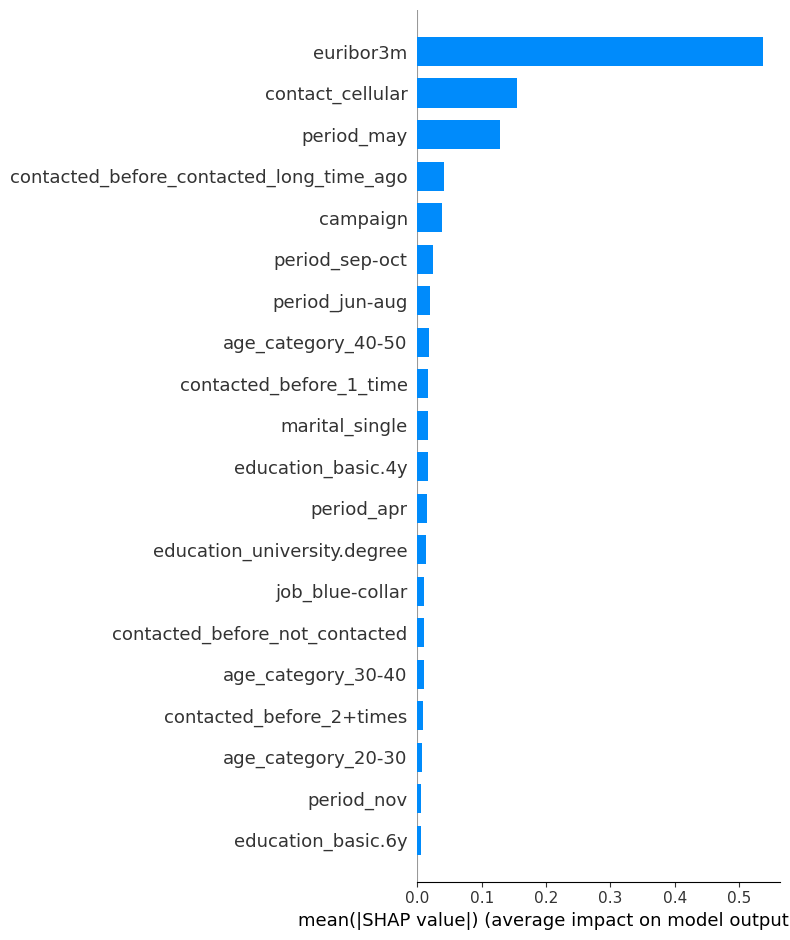

In [204]:
shap_values = shap.TreeExplainer(final_lgb_clf).shap_values(train_inputs) # Calculation of SHAP values
shap.summary_plot(shap_values, train_inputs, plot_type="bar")  # Construction of the SHAP summary plot

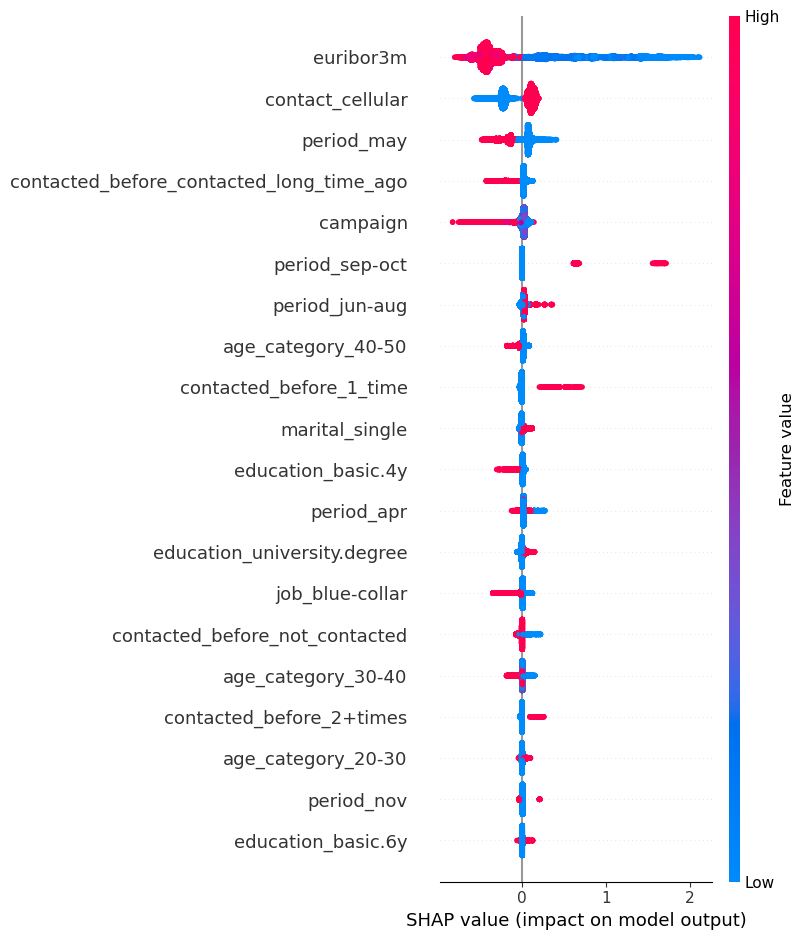

In [205]:
# Visualization of SHAP summary values for the training dataset
shap.summary_plot(shap_values, train_inputs)

# Test errors overview

In [207]:
from sklearn.metrics import confusion_matrix

In [208]:
COLORS = {
    'TP': '#43aa8b',
    'TN': '#f94144',
    'FP': '#f9844a',
    'FN': '#577590'
}

I am building a confusion matrix for the best model based on test_df.

The table displays the following Error types:
- **FP** (False Positive) — predicted *yes*, actually *no*
- **FN** (False Negative) — predicted *no*, actually *yes*
- **TP** (True Positive) — correctly predicted subscriber
- **TN** (True Negative) — correctly predicted non-subscriber

In [210]:
# Values of predictions from the best model
y_prob = final_lgb_clf.predict_proba(test_inputs)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Error table
err_df = test_df.copy()
err_df['y'] = (err_df['y'] == 'yes').astype(int)
err_df['y_pred'] = y_pred
err_df['y_prob'] = y_prob
err_df['correct'] = (test_target.values == y_pred).astype(int)
err_df['error_type'] = np.where(
    (err_df['y']==1) & (err_df['y_pred']==0), 'FN',
    np.where((err_df['y']==0) & (err_df['y_pred']==1), 'FP',
    np.where(err_df['y']==1, 'TP', 'TN')))
err_df.head()

,job,marital,education,contact,campaign,euribor3m,y,period,age_category,contacted_before,y_pred,y_prob,correct,error_type
28866,retired,not_single,basic.6y,cellular,2,1.41,0,apr,50-60,contacted_long_time_ago,0,0.46,1,TN
26436,entrepreneur,not_single,university.degree,cellular,2,4.08,0,nov,30-40,not_contacted,0,0.31,1,TN
7330,blue-collar,not_single,basic.9y,telephone,3,4.86,0,may,30-40,not_contacted,0,0.24,1,TN
2167,technician,not_single,professional.course,telephone,4,4.86,0,may,30-40,not_contacted,0,0.19,1,TN
35775,management,not_single,university.degree,cellular,2,1.27,1,may,30-40,1_time,1,0.69,1,TP


In [211]:
# I will build a table with statistics of the columns with the highest negative_rate

results = []
negative_classes = ['FP', 'FN']

for col in cat_cols:
    # calculate the distribution of error_type
    grouped = (
        err_df
        .groupby(col)['error_type']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    # calculate the absolute count
    counts = err_df.groupby(col).size().rename('count')

    for c in negative_classes:
        if c not in grouped.columns:
            grouped[c] = 0

    grouped['negative_rate'] = grouped[negative_classes].sum(axis=1)

    # add count
    grouped = grouped.join(counts)

    grouped = grouped.reset_index()
    grouped = grouped.rename(columns={col: 'value'})
    grouped['column'] = col

    grouped = grouped[['column', 'value', 'negative_rate', 'count']]

    results.append(grouped)

final_df = pd.concat(results, ignore_index=True)

# I will display only those values where the total count > 1000 and filter them by negative_rate
final_df[final_df['count']>1000].sort_values('negative_rate', ascending=False)

,column,value,negative_rate,count
39,contacted_before,contacted_long_time_ago,0.25,1013
20,education,university.degree,0.19,3026
31,age_category,20-30,0.18,1756
22,contact,cellular,0.18,6464
13,marital,single,0.18,2834
0,job,admin.,0.16,2602
34,age_category,50-60,0.15,1549
17,education,high.school,0.14,2344
19,education,professional.course,0.14,1297
12,marital,not_single,0.13,7359


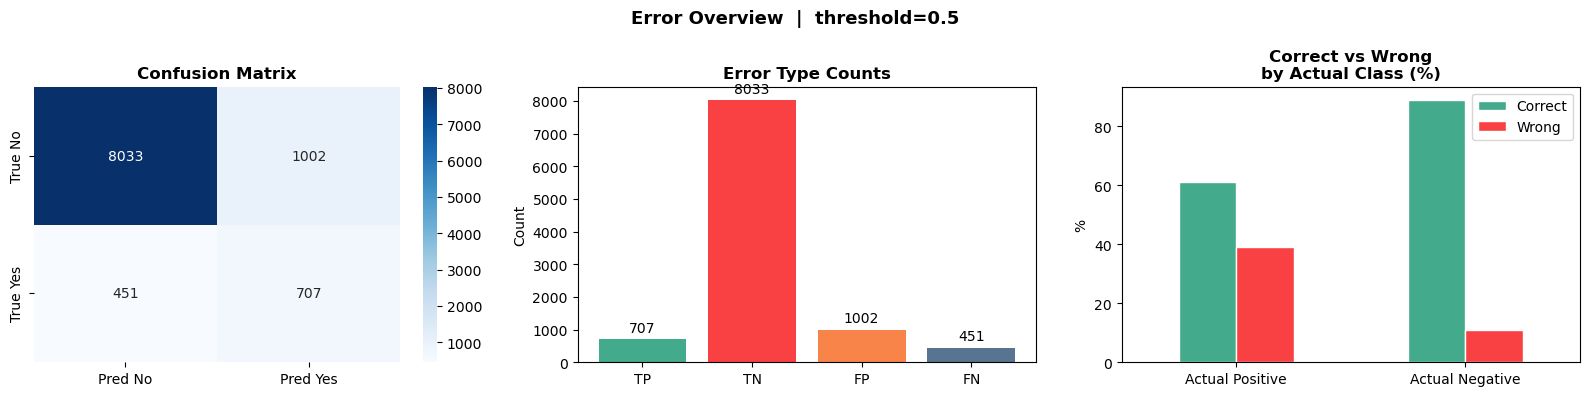

In [212]:
# Confusion matrix + error type breakdown 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(test_target, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No','Pred Yes'],
            yticklabels=['True No','True Yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Error type bar chart
type_counts = err_df['error_type'].value_counts().reindex(['TP','TN','FP','FN'])
bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=[COLORS[t] for t in type_counts.index])
axes[1].bar_label(bars, fmt='%d', padding=3)
axes[1].set_title('Error Type Counts', fontweight='bold')
axes[1].set_ylabel('Count')

# Error type as % of actual class
actual_pos = err_df[err_df['y']==1]
actual_neg = err_df[err_df['y']==0]
breakdown = pd.DataFrame({
    'Actual Positive': [
        (actual_pos['error_type']=='TP').mean()*100,
        (actual_pos['error_type']=='FN').mean()*100
    ],
    'Actual Negative': [
        (actual_neg['error_type']=='TN').mean()*100,
        (actual_neg['error_type']=='FP').mean()*100
    ]
}, index=['Correct','Wrong'])
breakdown.T.plot(kind='bar', color=['#43aa8b','#f94144',],
                  ax=axes[2], width=0.5, edgecolor='white')
axes[2].set_title('Correct vs Wrong\nby Actual Class (%)', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['Correct','Wrong'])

plt.suptitle(f'Error Overview  |  threshold={0.5}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

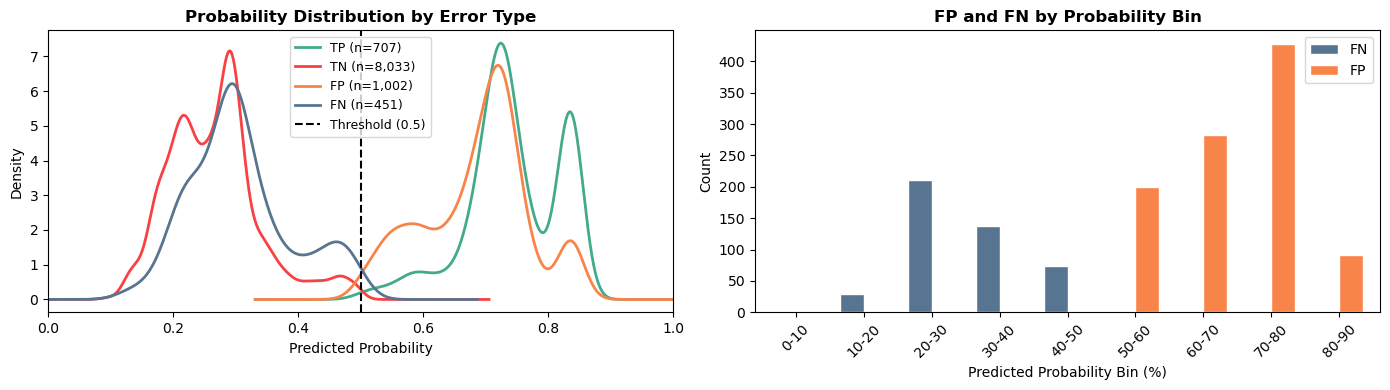

Mean predicted probability by error type:
            mean  std  min  50%  max
error_type                          
FN          0.31 0.08 0.12 0.29 0.50
FP          0.69 0.08 0.50 0.70 0.84
TN          0.27 0.07 0.09 0.27 0.50
TP          0.74 0.07 0.50 0.73 0.84


In [213]:
# Model's confidence analysis in its errors

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


# PROBABILITY DISTRIBUTION FOR EACH ERROR TYPE

for err_type, color in COLORS.items():
    subset = err_df[err_df['error_type'] == err_type]['y_prob']
    
    if len(subset) > 0:
        subset.plot.kde(
            ax=axes[0],
            label=f'{err_type} (n={len(subset):,})',
            color=color,
            linewidth=2
        )

# Displaying the current classification threshold
axes[0].axvline(
    0.5,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Threshold ({0.5})'
)

axes[0].set_xlabel('Predicted Probability')
axes[0].set_title('Probability Distribution by Error Type', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)


# ERROR CONCENTRATION ANALYSIS BY PROBABILITY BINS

err_df['prob_bin'] = pd.cut(
    err_df['y_prob'],
    bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
    labels=[
        '0-10', '10-20', '20-30', '30-40', '40-50',
        '50-60', '60-70', '70-80', '80-90', '90-100'
    ]
)

# Counting the number of errors (FP and FN) in each bin
bin_errors = err_df.groupby('prob_bin', observed=True)['error_type'] \
                   .value_counts() \
                   .unstack(fill_value=0)

# Visualization of errors (FP and FN)
bin_errors[['FN', 'FP']].plot(
    kind='bar',
    ax=axes[1],
    color=[COLORS['FN'], COLORS['FP']],
    edgecolor='white',
    width=0.7
)

axes[1].set_xlabel('Predicted Probability Bin (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('FP and FN by Probability Bin', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


# DESCRIPTIVE STATISTICS OF PROBABILITIES FOR EACH ERROR TYPE
print('Mean predicted probability by error type:')
print(
    err_df
    .groupby('error_type')['y_prob']
    .describe()[['mean', 'std', 'min', '50%', 'max']]
    .round(3)
)

The distribution of predicted probabilities shows that:
- False Negatives predominantly fall within the range of ≈0.2–0.4
- In contrast, False Positives concentrate in the range of ≈0.5–0.8

The model makes significantly more mistakes in predicting the positive class? At the same time, the FP line starts significantly above the TP line, indicating that the fixed threshold of 0.5 is not optimal.

# Threshold Tuning

I will conduct an experiment to find the optimal level of thresholds.

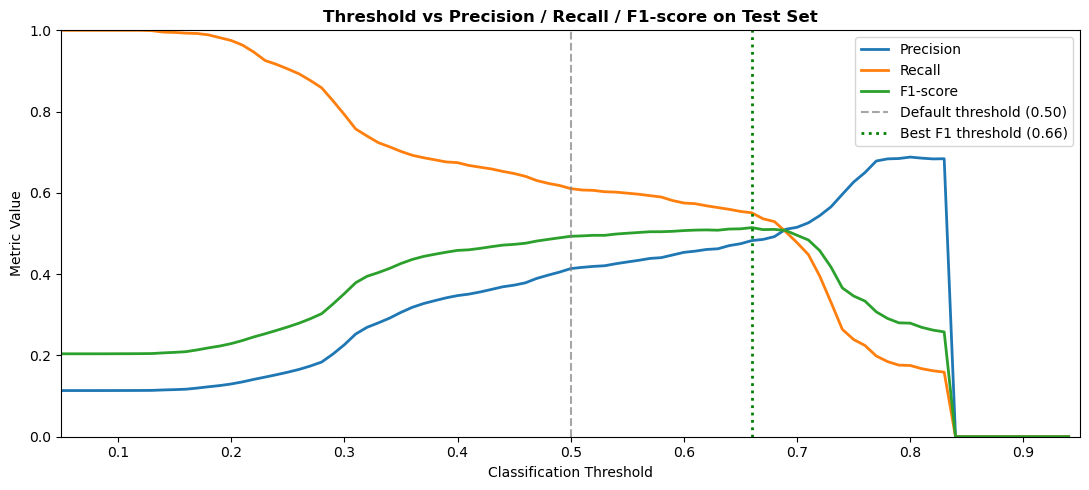

Default threshold (0.50): F1 = 0.4932
Best F1 threshold (0.66): F1 = 0.5145

Classification report on test set using best F1 threshold (0.66):
              precision    recall  f1-score   support

          no       0.94      0.92      0.93      9035
         yes       0.48      0.55      0.51      1158

    accuracy                           0.88     10193
   macro avg       0.71      0.74      0.72     10193
weighted avg       0.89      0.88      0.89     10193



In [217]:
# Experiment to find the optimal threshold

# Getting the probabilities of the positive class
y_prob_test = final_lgb_clf.predict_proba(test_inputs)[:, 1]

# Range of thresholds
thresholds = np.arange(0.05, 0.95, 0.01)

# Lists for metrics
precisions = []
recalls = []
f1s = []

# Calculating metrics for each threshold
for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)

    precisions.append(precision_score(test_target, y_pred_t, zero_division=0))
    recalls.append(recall_score(test_target, y_pred_t, zero_division=0))
    f1s.append(f1_score(test_target, y_pred_t, zero_division=0))

# Best threshold by F1
best_idx = np.argmax(f1s)
best_threshold_f1 = thresholds[best_idx].round(2)
best_f1 = f1s[best_idx]

# Index for the default threshold = 0.50
default_idx = np.argmin(np.abs(thresholds - 0.50))
default_f1 = f1s[default_idx]

# Building the plot
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(thresholds, precisions, label='Precision', linewidth=2)
ax.plot(thresholds, recalls, label='Recall', linewidth=2)
ax.plot(thresholds, f1s, label='F1-score', linewidth=2)

# Line for the default threshold
ax.axvline(
    0.50,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='Default threshold (0.50)'
)

# Line for the best F1 threshold
ax.axvline(
    best_threshold_f1,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'Best F1 threshold ({best_threshold_f1:.2f})'
)

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Metric Value')
ax.set_title('Threshold vs Precision / Recall / F1-score on Test Set', fontweight='bold')
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

# Output results
print(f'Default threshold (0.50): F1 = {default_f1:.4f}')
print(f'Best F1 threshold ({best_threshold_f1:.2f}): F1 = {best_f1:.4f}')

# Evaluating the model with the optimal threshold
y_pred_test_tuned = (y_prob_test >= best_threshold_f1).astype(int)

print(f'\nClassification report on test set using best F1 threshold ({best_threshold_f1:.2f}):')
print(classification_report(test_target, y_pred_test_tuned, target_names=['no', 'yes']))

# Test errors overview with a new threshold

In [219]:
# Update the error dataframe
y_pred = (y_prob >= best_threshold_f1).astype(int)
err_df['y_pred'] = y_pred
err_df['correct'] = (test_target.values == y_pred).astype(int)
err_df['error_type'] = np.where(
    (err_df['y']==1) & (err_df['y_pred']==0), 'FN',
    np.where((err_df['y']==0) & (err_df['y_pred']==1), 'FP',
    np.where(err_df['y']==1, 'TP', 'TN')))
err_df.head()

,job,marital,education,contact,campaign,euribor3m,y,period,age_category,contacted_before,y_pred,y_prob,correct,error_type,prob_bin
28866,retired,not_single,basic.6y,cellular,2,1.41,0,apr,50-60,contacted_long_time_ago,0,0.46,1,TN,40-50
26436,entrepreneur,not_single,university.degree,cellular,2,4.08,0,nov,30-40,not_contacted,0,0.31,1,TN,30-40
7330,blue-collar,not_single,basic.9y,telephone,3,4.86,0,may,30-40,not_contacted,0,0.24,1,TN,20-30
2167,technician,not_single,professional.course,telephone,4,4.86,0,may,30-40,not_contacted,0,0.19,1,TN,10-20
35775,management,not_single,university.degree,cellular,2,1.27,1,may,30-40,1_time,1,0.69,1,TP,60-70


Let's take a look at the updated error distribution chart.

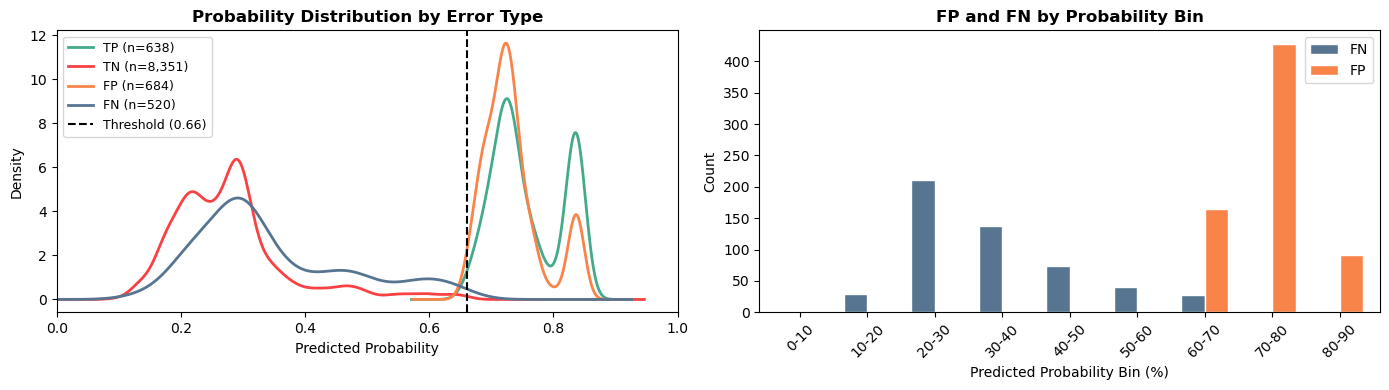

Mean predicted probability by error type:
            mean  std  min  50%  max
error_type                          
FN          0.34 0.12 0.12 0.30 0.66
FP          0.73 0.05 0.66 0.72 0.84
TN          0.28 0.10 0.09 0.27 0.66
TP          0.76 0.06 0.66 0.74 0.84


In [221]:
# Creating a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


# --- LEFT GRAPH: KDE probability distribution by error types ---

# For each type of error (FN, FP, TP, TN) we build the probability distribution
for err_type, color in COLORS.items():
    
    # Selecting a subset of data for a specific type of error
    subset = err_df[err_df['error_type'] == err_type]['y_prob']
    
    # Checking that the subset is not empty
    if len(subset) > 0:
        
        # Building KDE (kernel density estimation)
        subset.plot.kde(
            ax=axes[0],
            label=f'{err_type} (n={len(subset):,})',  # label with the number of observations
            color=color,
            linewidth=2
        )

# Adding a vertical line for the selected threshold
axes[0].axvline(
    best_threshold_f1,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Threshold ({best_threshold_f1})'
)

# Labels and settings for the graph
axes[0].set_xlabel('Predicted Probability')
axes[0].set_title('Probability Distribution by Error Type', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)


# --- RIGHT GRAPH: count of FP and FN by probability intervals ---

# Dividing probabilities into bin intervals (0–10%, 10–20%, ..., 90–100%)
err_df['prob_bin'] = pd.cut(
    err_df['y_prob'],
    bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
    labels=[
        '0-10', '10-20', '20-30', '30-40', '40-50',
        '50-60', '60-70', '70-80', '80-90', '90-100'
    ]
)

# Grouping the data:
# for each bin, counting the number of each type of error
bin_errors = (
    err_df
    .groupby('prob_bin', observed=True)['error_type']
    .value_counts()
    .unstack(fill_value=0)
)

# Building a bar chart only for FP and FN
bin_errors[['FN', 'FP']].plot(
    kind='bar',
    ax=axes[1],
    color=[COLORS['FN'], COLORS['FP']],
    edgecolor='white',
    width=0.7
)

# Labels and settings for the graph
axes[1].set_xlabel('Predicted Probability Bin (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('FP and FN by Probability Bin', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()


# Automatic adjustment of margins
plt.tight_layout()

# Displaying the graphs
plt.show()


# TABLE OF STATISTICS BY PROBABILITIES FOR EACH TYPE OF ERROR

print('Mean predicted probability by error type:')

# Grouping by error type and displaying descriptive statistics
print(
    err_df
    .groupby('error_type')['y_prob']
    .describe()[['mean', 'std', 'min', '50%', 'max']]
    .round(3)
)

# Metrics for model with new threshold

In [223]:
train_proba = final_lgb_clf.predict_proba(train_inputs)[:, 1]
test_proba = final_lgb_clf.predict_proba(test_inputs)[:, 1]

train_pred = (train_proba >= best_threshold_f1).astype(int)
test_pred = (test_proba >= best_threshold_f1).astype(int)

all_results[f'LightGBM with {best_threshold_f1:.2f} threshold'] = {
    'train': {
        'accuracy': accuracy_score(train_target, train_pred),
        'precision': precision_score(train_target, train_pred, zero_division=0),
        'recall': recall_score(train_target, train_pred, zero_division=0),
        'f1': f1_score(train_target, train_pred, zero_division=0),
        'roc_auc': roc_auc_score(train_target, train_proba)
    },
    'test': {
        'accuracy': accuracy_score(test_target, test_pred),
        'precision': precision_score(test_target, test_pred, zero_division=0),
        'recall': recall_score(test_target, test_pred, zero_division=0),
        'f1': f1_score(test_target, test_pred, zero_division=0),
        'roc_auc': roc_auc_score(test_target, test_proba)
    }
}

In [224]:
# Final summary
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows = []
for model_name, res in all_results.items():
    for split in ['train', 'test']:
        row = {'model': model_name, 'split': split}
        row.update(res[split])
        rows.append(row)

comp_df = pd.DataFrame(rows)
train_comp = comp_df[comp_df['split'] == 'train'].set_index('model')[metrics]
test_comp = comp_df[comp_df['split'] == 'test'].set_index('model')[metrics]

print('='*20, 'TRAIN SET METRICS', '='*20)
display(train_comp.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.4f}'))

print()
print('='*20, 'TEST SET METRICS',  '='*20)
display(test_comp.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.4f}'))

==================== TRAIN SET METRICS ====================


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.8864,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7929,0.3079,0.6595,0.4198,0.7866
KNN,0.8910,0.7660,0.0584,0.1086,0.7922
Decision Tree,0.8245,0.3544,0.6632,0.4620,0.8021
XGBoost + Random search,0.8767,0.4639,0.5461,0.5017,0.8066
XGBoost + Hyperopt,0.8433,0.3922,0.6891,0.4999,0.8668
LightGBM,0.8585,0.4176,0.6226,0.4999,0.8181
LightGBM with 0.66 threshold,0.8789,0.4715,0.5455,0.5058,0.8181



==================== TEST SET METRICS ====================


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.8864,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7964,0.3129,0.6623,0.4250,0.7932
KNN,0.8892,0.6790,0.0475,0.0888,0.7908
Decision Tree,0.8247,0.3539,0.6580,0.4603,0.8010
XGBoost + Random search,0.8804,0.4771,0.5492,0.5106,0.8072
XGBoost + Hyperopt,0.8365,0.3729,0.6451,0.4726,0.8135
LightGBM,0.8575,0.4137,0.6105,0.4932,0.8143
LightGBM with 0.66 threshold,0.8819,0.4826,0.5509,0.5145,0.8143
